Importem llibreries y gràfica

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuració estètica
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Importem DF

##### ESTA ANALISIS LO HICE QUITANDO LOS VALORES 0 DE MOUNTH ABS. Y TAMBIEN HICE POR FRECUENCIA Y HORAS, PARA MI, FRECUENCIA NO TIENE MUCHO SENTIDO ENTONCES NOS QUEDAMOS CON HORAS.

In [111]:
# Instalar pyarrow si no lo tienes
# !pip install pyarrow

import pandas as pd

# Leer el archivo Parquet correctamente
RRHH = pd.read_parquet(r"C:\Users\Lucan Vieira\ProjecteData\Equip_15\Data\RRHH_220925_clean.parquet")

# Mostrar las primeras filas para verificar
print(RRHH.head())

   ID Reason_absence Month_absence   Day_week    Seasons  \
0  14             11     Noviembre      Lunes  Primavera   
1  36             13         Abril  Miercoles     Verano   
2   9              6         Julio     Martes   Invierno   
3  28              9         Julio     Martes   Invierno   
4   9             12         Marzo     Martes      Otono   

   Transportation_expense  Distance_Residence_Work  Service_time   Age  \
0                   155.0                     12.0          14.0  34.0   
1                   118.0                     13.0          18.0  50.0   
2                   228.0                     14.0          16.0  58.0   
3                   225.0                     26.0           9.0  28.0   
4                   228.0                     14.0          16.0  58.0   

   Work_load_Average_day  ...  Social_smoker  Pet Weight  Height  \
0                284.031  ...              0    0   95.0   196.0   
1                239.409  ...              0    0   98.0  

In [112]:
print("Tipos de datos por columna:")
print(RRHH.dtypes)

# Información detallada
print("\nInformación completa del dataset:")
print(RRHH.info())

# Estadísticas descriptivas por tipo de dato
print("\nResumen de datos numéricos:")
print(RRHH.describe())


Tipos de datos por columna:
ID                                  int64
Reason_absence             string[python]
Month_absence              string[python]
Day_week                   string[python]
Seasons                    string[python]
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Hit_target                        float64
Disciplinary_failure                int64
Education                  string[python]
Son                                 int64
Social_drinker                      int64
Social_smoker                       int64
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Absenteeism_hours                 float64
Education_numeric                   int64
Month_absence_order                 int64
Day_we

In [113]:
df= RRHH
print (df)

      ID Reason_absence Month_absence   Day_week    Seasons  \
0     14             11     Noviembre      Lunes  Primavera   
1     36             13         Abril  Miercoles     Verano   
2      9              6         Julio     Martes   Invierno   
3     28              9         Julio     Martes   Invierno   
4      9             12         Marzo     Martes      Otono   
..   ...            ...           ...        ...        ...   
801  132             19       Febrero     Jueves      Otono   
802  133             23        Agosto    Viernes   Invierno   
803  134             23         Julio    Viernes   Invierno   
804  135             23         Marzo      Lunes      Otono   
805  136             23          Mayo  Miercoles     Verano   

     Transportation_expense  Distance_Residence_Work  Service_time   Age  \
0                     155.0                     12.0          14.0  34.0   
1                     118.0                     13.0          18.0  50.0   
2              

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Cargar datos (asumiendo que ya tienes el DataFrame)
# df = pd.read_csv('tu_archivo.csv')

# Eliminar registros con Month_absence = '0'
print(f"Registros antes de limpiar: {len(df)}")
df_clean = df[df['Month_absence'] != '0'].copy()
print(f"Registros después de limpiar: {len(df_clean)}")
print(f"Registros eliminados: {len(df) - len(df_clean)}")

Registros antes de limpiar: 806
Registros después de limpiar: 801
Registros eliminados: 5


In [115]:
# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Variables personales vs laborales
variables_personales = ['Son', 'Social_drinker', 'Education_numeric', 'Age', 
                       'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index']

variables_laborales = [
                       
                      'Service_time', 'Work_load_Average_day', 'Hit_target', 
                      'Disciplinary_failure']

target_variable = 'Absenteeism_hours'

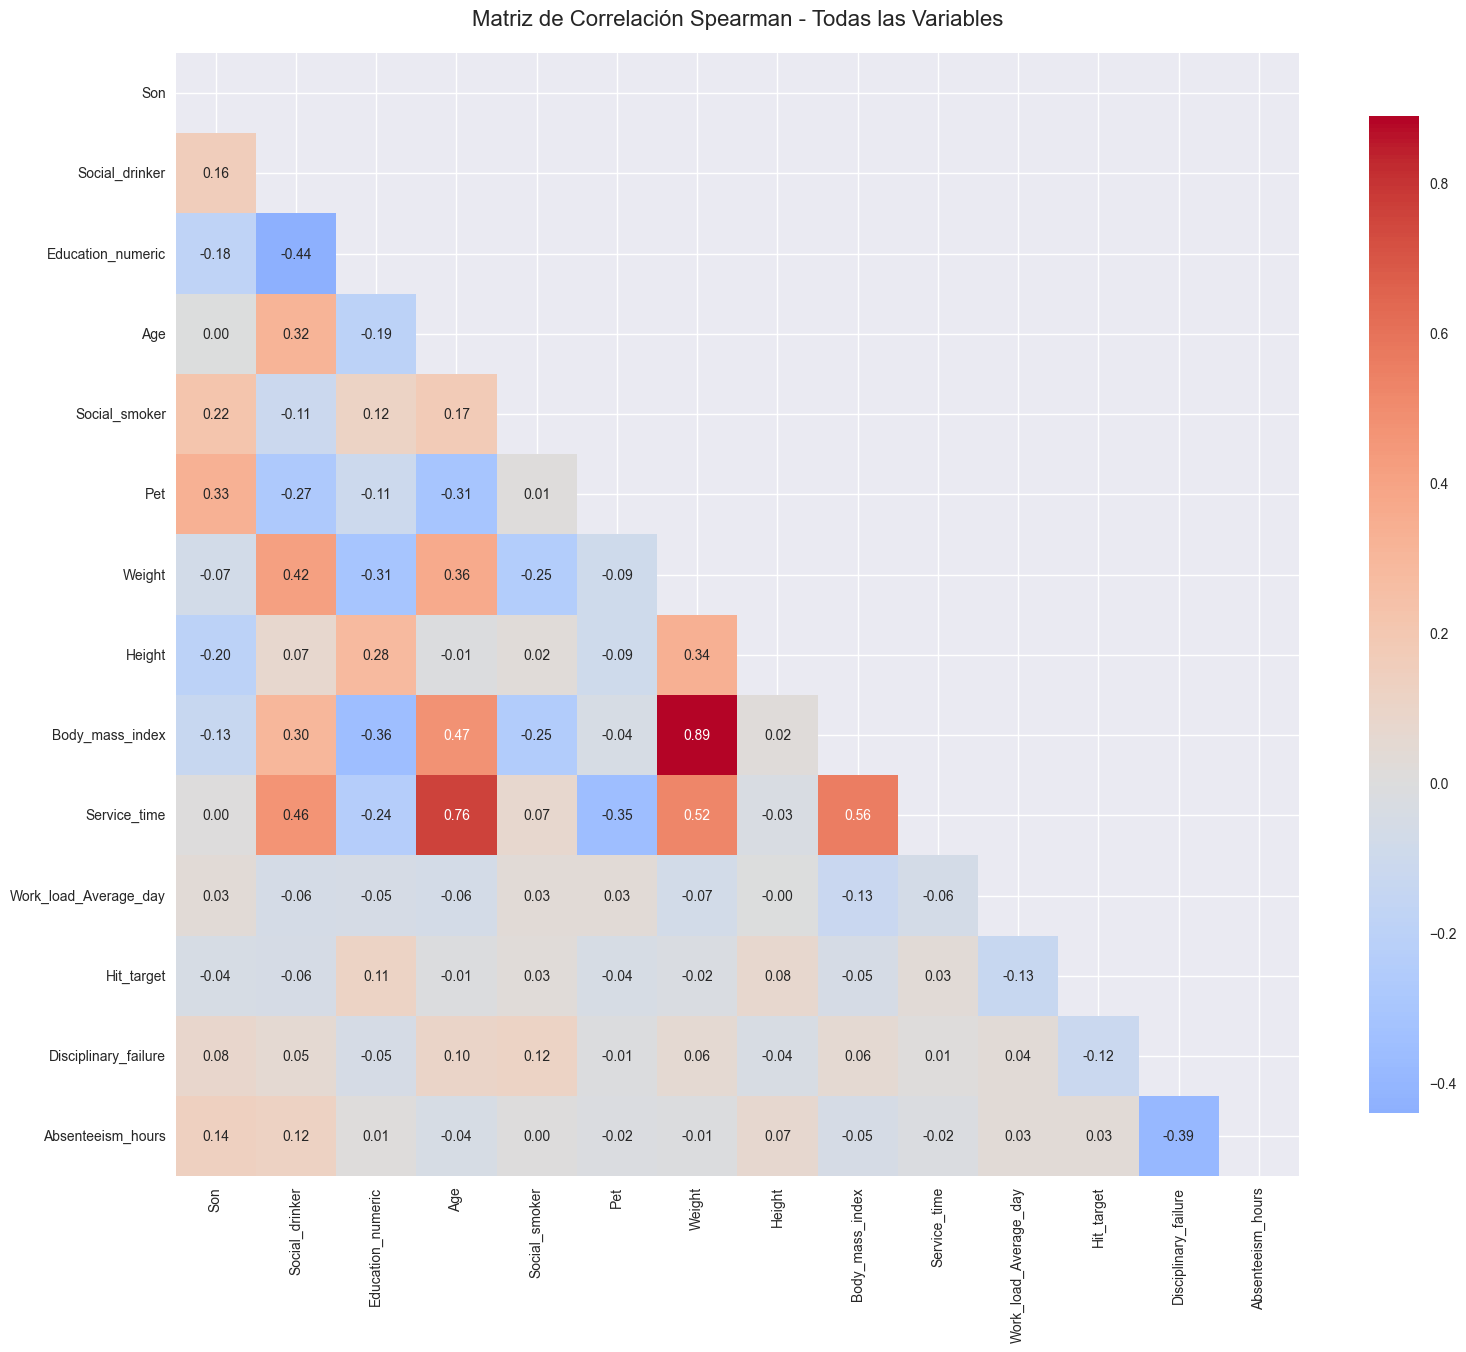

In [116]:
# Combinar todas las variables relevantes
todas_variables = variables_personales + variables_laborales + [target_variable]

# Matriz de correlación Spearman
corr_spearman = df_clean[todas_variables].corr(method='spearman')

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, mask=mask, annot=True, cmap='coolwarm', center=0,
           square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación Spearman - Todas las Variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

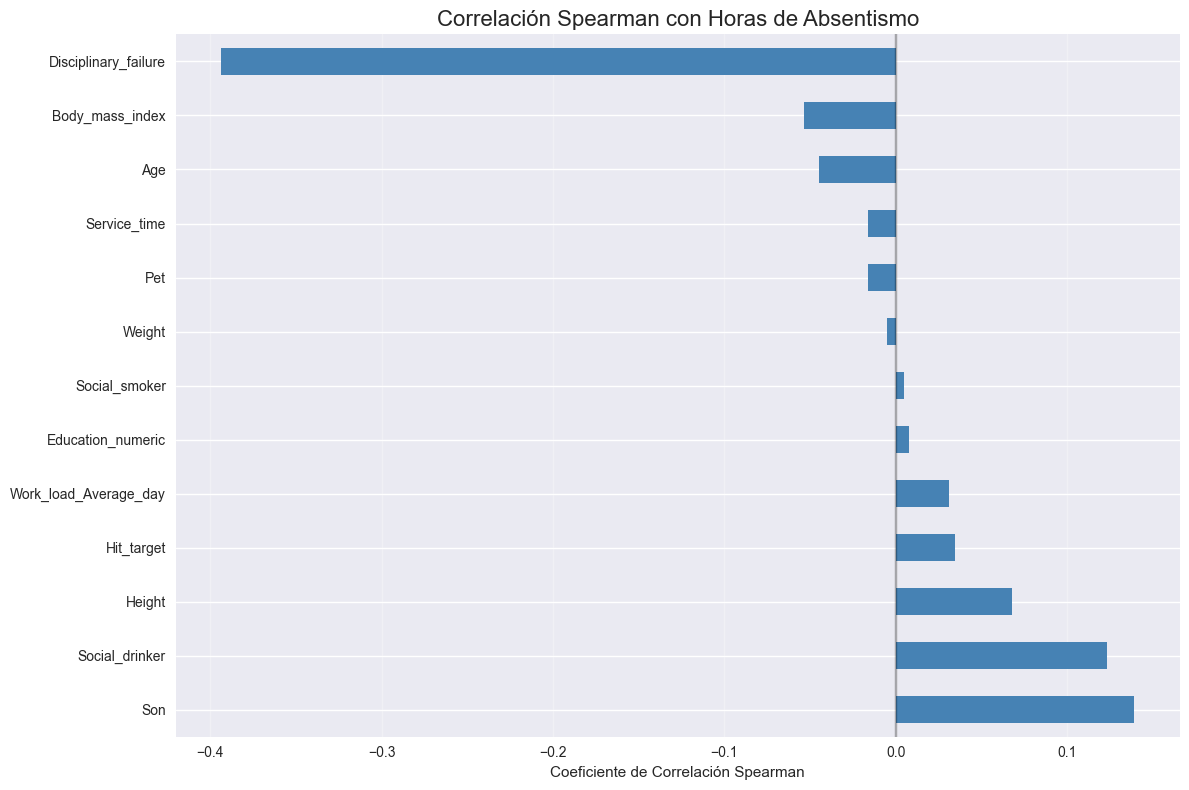

Top 5 variables con mayor correlación Spearman:
Son                      0.139111
Social_drinker           0.123040
Height                   0.067824
Hit_target               0.034293
Work_load_Average_day    0.030838
Education_numeric        0.007824
Social_smoker            0.004704
Weight                  -0.005323
Pet                     -0.015976
Service_time            -0.016264
dtype: float64


In [117]:
# Correlaciones con la variable objetivo
correlaciones_objetivo = df_clean[todas_variables].corrwith(df_clean['Absenteeism_hours'], method='spearman')
correlaciones_objetivo = correlaciones_objetivo.drop('Absenteeism_hours').sort_values(ascending=False)

plt.figure(figsize=(12, 8))
correlaciones_objetivo.plot(kind='barh', color='steelblue')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.title('Correlación Spearman con Horas de Absentismo', fontsize=16)
plt.xlabel('Coeficiente de Correlación Spearman')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 variables con mayor correlación Spearman:")
print(correlaciones_objetivo.head(10))

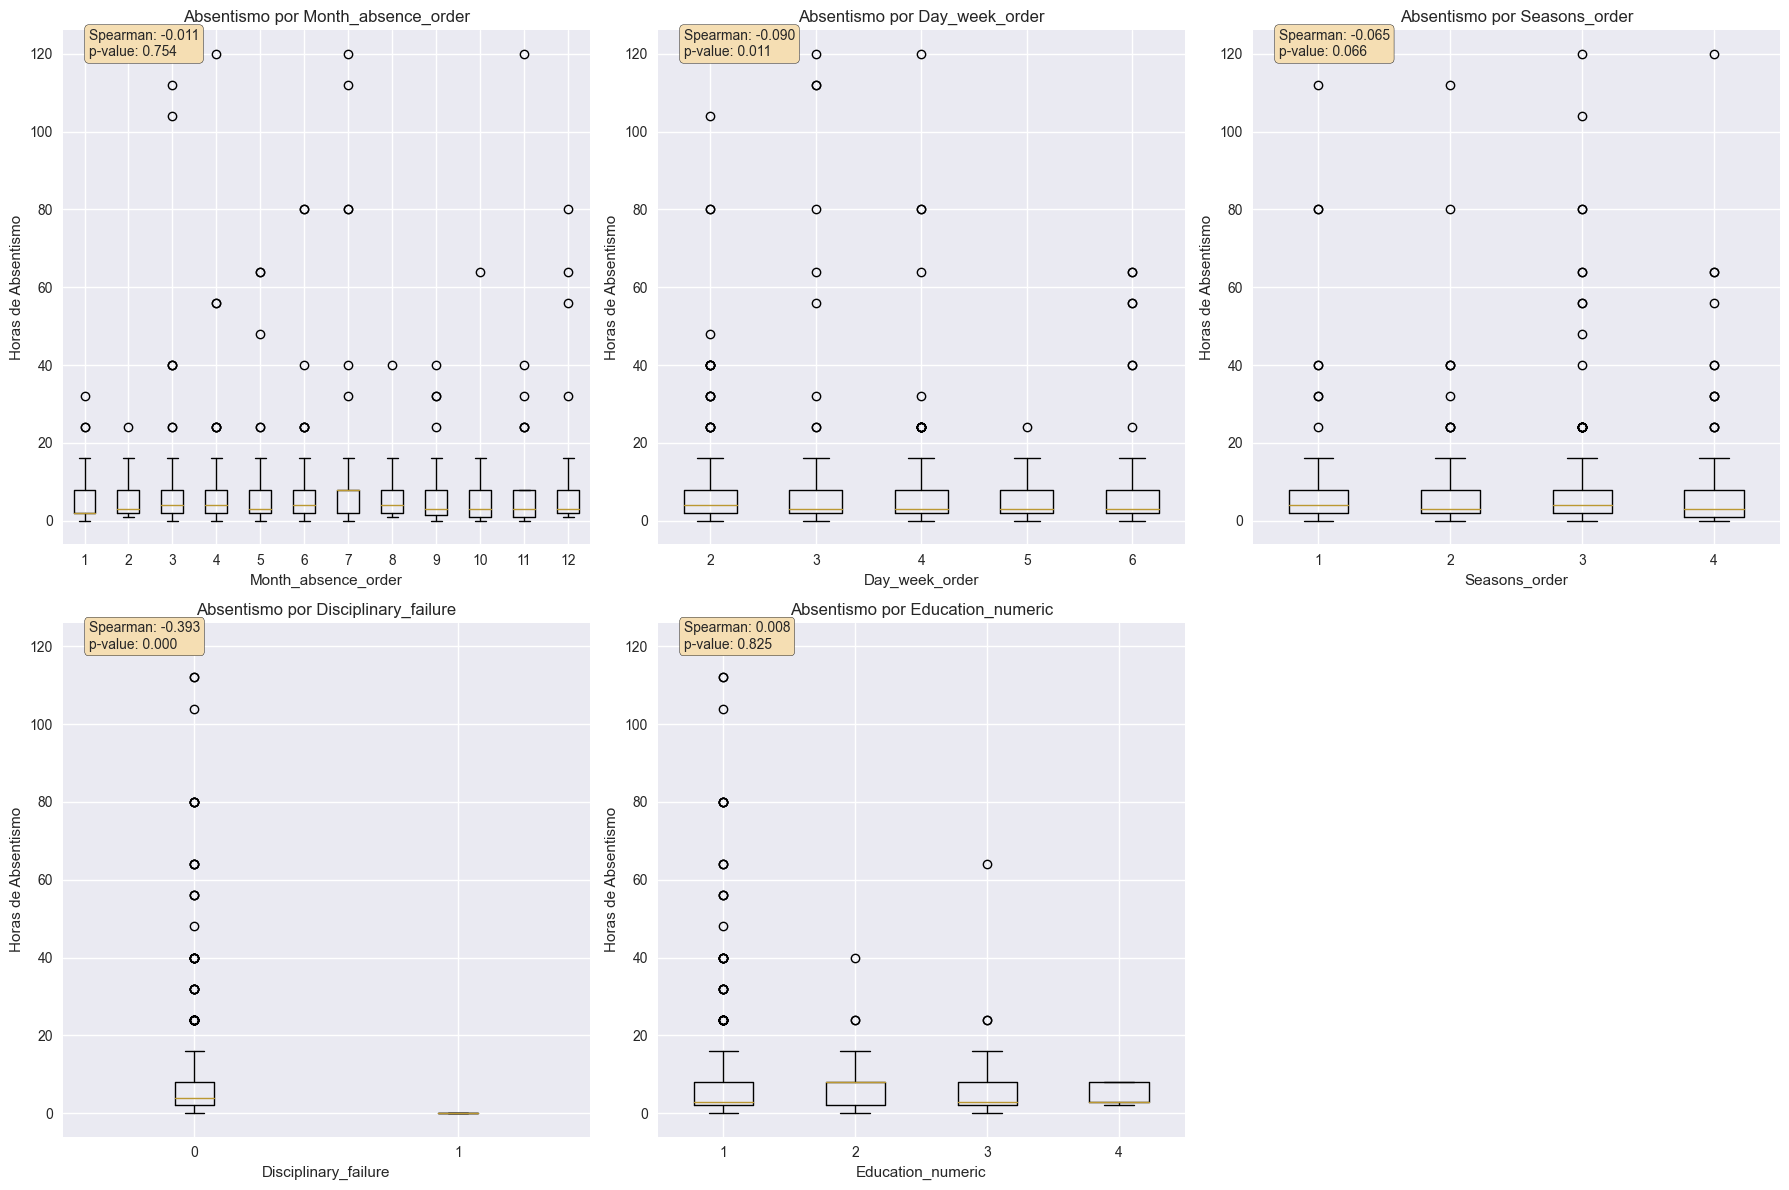

In [118]:
# Boxplots para variables categóricas ordenadas
categorical_vars = ['Month_absence_order', 'Day_week_order', 'Seasons_order', 
                   'Disciplinary_failure', 'Education_numeric']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, var in enumerate(categorical_vars):
    # Agrupar por categorías y crear boxplot
    data_to_plot = []
    categories = sorted(df_clean[var].unique())
    
    for category in categories:
        data_to_plot.append(df_clean[df_clean[var] == category]['Absenteeism_hours'])
    
    axes[i].boxplot(data_to_plot, labels=categories)
    axes[i].set_title(f'Absentismo por {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Horas de Absentismo')
    
    # Calcular correlación Spearman
    corr, p_value = spearmanr(df_clean[var], df_clean['Absenteeism_hours'])
    axes[i].text(0.05, 0.95, f'Spearman: {corr:.3f}\np-value: {p_value:.3f}', 
                transform=axes[i].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))

# Ocultar el último subplot si no se usa
if len(categorical_vars) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

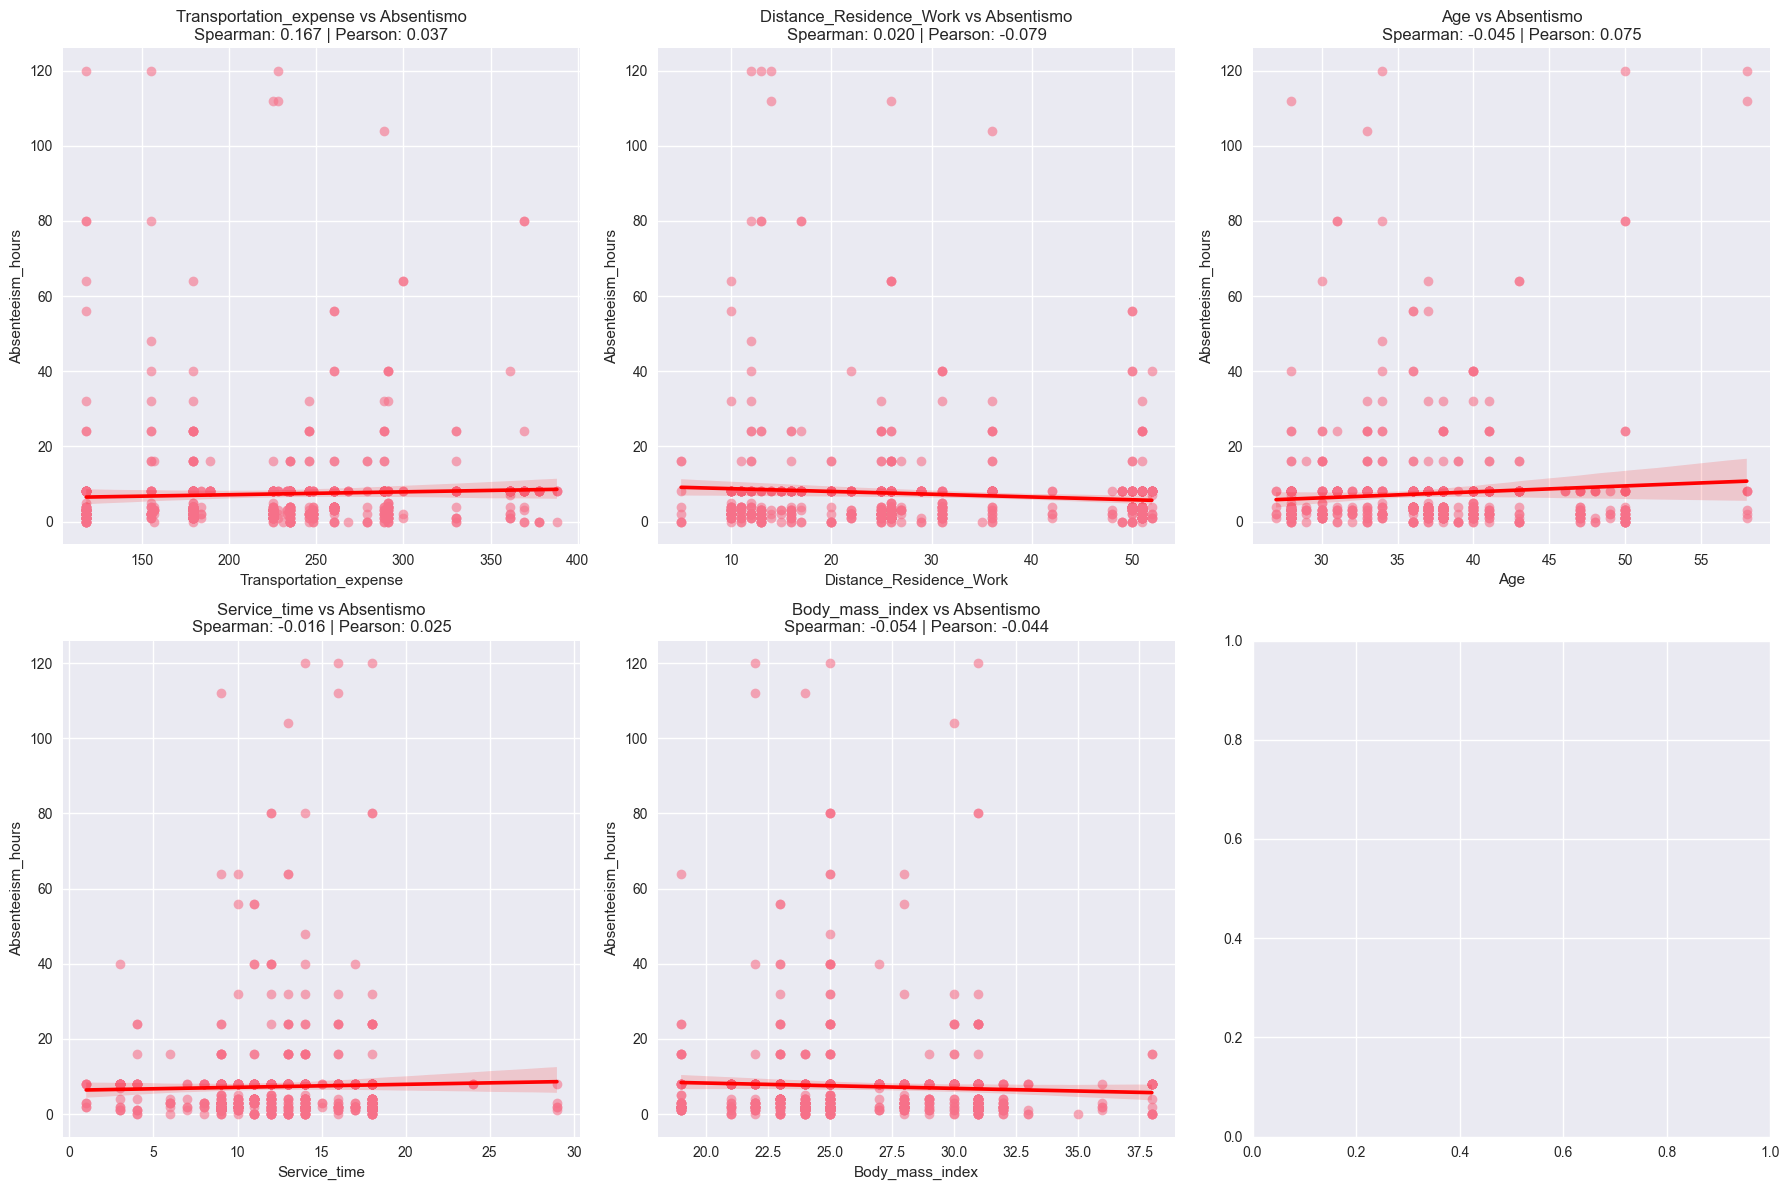

In [119]:
# Variables continuas más prometedoras
continuous_vars = ['Transportation_expense', 'Distance_Residence_Work', 'Age', 
                  'Service_time', 'Body_mass_index']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, var in enumerate(continuous_vars):
    if i < len(continuous_vars):
        # Scatter plot con línea de tendencia
        sns.regplot(data=df_clean, x=var, y='Absenteeism_hours', 
                   ax=axes[i], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
        
        # Calcular ambas correlaciones
        spear_corr, spear_p = spearmanr(df_clean[var], df_clean['Absenteeism_hours'])
        pearson_corr, pearson_p = pearsonr(df_clean[var], df_clean['Absenteeism_hours'])
        
        axes[i].set_title(f'{var} vs Absentismo\nSpearman: {spear_corr:.3f} | Pearson: {pearson_corr:.3f}')
        axes[i].set_xlabel(var)

# Ajustar layout
plt.tight_layout()
plt.show()

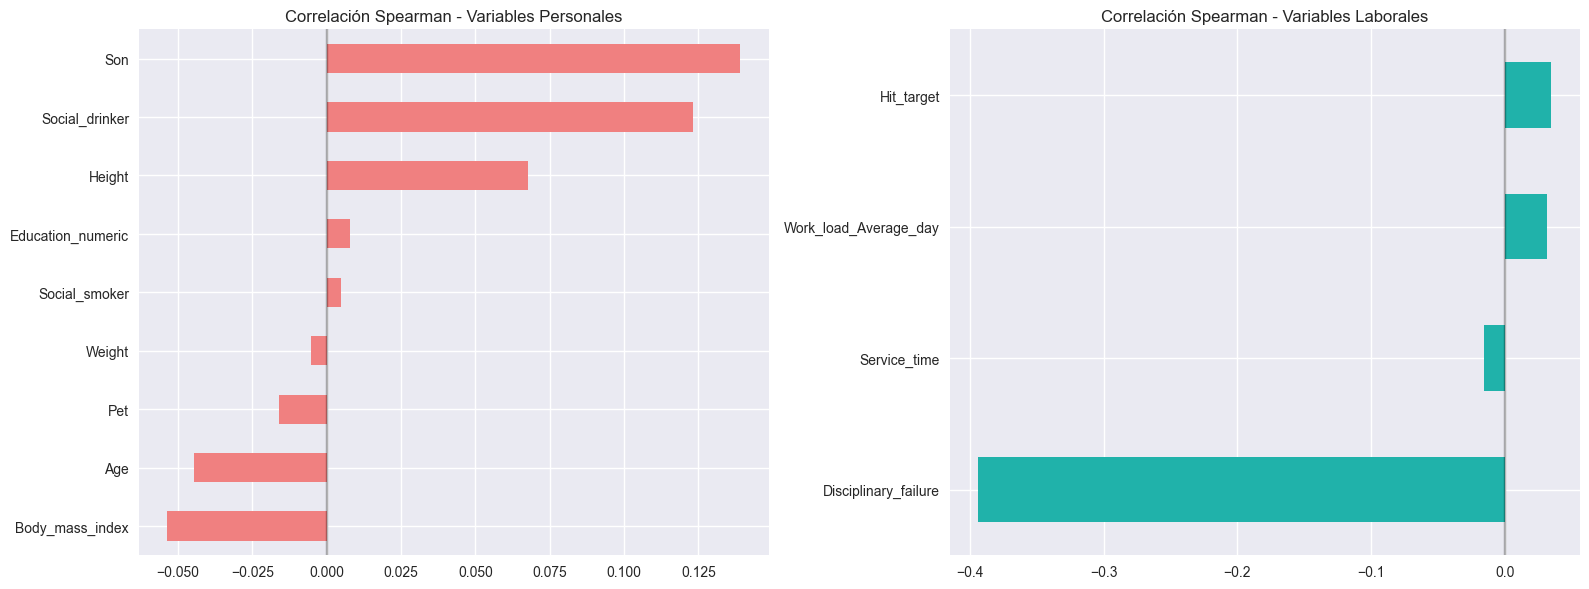

Resumen de correlaciones promedio:
Variables personales: 0.051
Variables laborales: 0.119


In [120]:
# Comparar correlaciones entre grupos
corr_personal = df_clean[variables_personales + ['Absenteeism_hours']].corrwith(
    df_clean['Absenteeism_hours'], method='spearman').drop('Absenteeism_hours')

corr_laboral = df_clean[variables_laborales + ['Absenteeism_hours']].corrwith(
    df_clean['Absenteeism_hours'], method='spearman').drop('Absenteeism_hours')

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Variables personales
corr_personal.sort_values().plot(kind='barh', ax=ax1, color='lightcoral')
ax1.set_title('Correlación Spearman - Variables Personales')
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Variables laborales
corr_laboral.sort_values().plot(kind='barh', ax=ax2, color='lightseagreen')
ax2.set_title('Correlación Spearman - Variables Laborales')
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

print("Resumen de correlaciones promedio:")
print(f"Variables personales: {corr_personal.abs().mean():.3f}")
print(f"Variables laborales: {corr_laboral.abs().mean():.3f}")

In [121]:
# Tabla resumen de correlaciones
resumen_correlaciones = []

for variable in todas_variables:
    if variable != 'Absenteeism_hours':
        spear_corr, spear_p = spearmanr(df_clean[variable], df_clean['Absenteeism_hours'])
        pearson_corr, pearson_p = pearsonr(df_clean[variable], df_clean['Absenteeism_hours'])
        
        resumen_correlaciones.append({
            'Variable': variable,
            'Tipo': 'Personal' if variable in variables_personales else 'Laboral',
            'Spearman_Corr': spear_corr,
            'Spearman_p_value': spear_p,
            'Pearson_Corr': pearson_corr,
            'Pearson_p_value': pearson_p,
            'Significativo_Spearman': spear_p < 0.05,
            'Significativo_Pearson': pearson_p < 0.05
        })

df_resumen = pd.DataFrame(resumen_correlaciones)
df_resumen = df_resumen.sort_values('Spearman_Corr', key=abs, ascending=False)

print("Resumen Estadístico de Correlaciones:")
print("="*80)
print(df_resumen.to_string(index=False))

# Variables más significativas
print("\n" + "="*80)
print("VARIABLES MÁS RELEVANTES (p-value < 0.05):")
print("="*80)

significativas = df_resumen[df_resumen['Significativo_Spearman']].sort_values('Spearman_Corr', key=abs, ascending=False)
print(significativas[['Variable', 'Tipo', 'Spearman_Corr', 'Spearman_p_value']].to_string(index=False))

Resumen Estadístico de Correlaciones:
             Variable     Tipo  Spearman_Corr  Spearman_p_value  Pearson_Corr  Pearson_p_value  Significativo_Spearman  Significativo_Pearson
 Disciplinary_failure  Laboral      -0.393486      4.641590e-31     -0.125583         0.000367                    True                   True
                  Son Personal       0.139111      7.809078e-05      0.122301         0.000522                    True                   True
       Social_drinker Personal       0.123040      4.828381e-04      0.085826         0.015110                    True                   True
               Height Personal       0.067824      5.501584e-02      0.126537         0.000331                   False                   True
      Body_mass_index Personal      -0.053538      1.300381e-01     -0.043909         0.214474                   False                  False
                  Age Personal      -0.044656      2.067697e-01      0.074946         0.033939                

In [122]:
# Identificar outliers en absenteeism hours
Q1 = df_clean['Absenteeism_hours'].quantile(0.25)
Q3 = df_clean['Absenteeism_hours'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_clean[df_clean['Absenteeism_hours'] > limite_superior]
print(f"\nAnálisis de Outliers:")
print(f"Límite superior para outliers: {limite_superior:.2f} horas")
print(f"Número de outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")
print(f"Horas máximas de absentismo: {df_clean['Absenteeism_hours'].max():.2f}")


Análisis de Outliers:
Límite superior para outliers: 17.00 horas
Número de outliers: 52 (6.5%)
Horas máximas de absentismo: 120.00


#### analisis por frecuencia 


In [123]:
# PRIMERO: Agrupar por empleado para calcular FRECUENCIA
frecuencia_ausencias = df_clean.groupby('ID').agg({
    'Absenteeism_hours': 'count',  # Esto será la FRECUENCIA
    'Son': 'first',
    'Social_drinker': 'first', 
    'Education_numeric': 'first',
    'Age': 'first',
    'Social_smoker': 'first',
    'Pet': 'first',
    'Weight': 'first',
    'Height': 'first',
    'Body_mass_index': 'first',
    'Transportation_expense': 'first',
    'Distance_Residence_Work': 'first',
    'Service_time': 'first',
    'Work_load_Average_day': 'first',
    'Hit_target': 'first',
    'Disciplinary_failure': 'first'
}).reset_index()

frecuencia_ausencias = frecuencia_ausencias.rename(columns={'Absenteeism_hours': 'Frecuencia_ausencias'})

print(f"Número de empleados únicos: {len(frecuencia_ausencias)}")
print(f"Frecuencia de ausencias por empleado:")
print(frecuencia_ausencias['Frecuencia_ausencias'].describe())

Número de empleados únicos: 132
Frecuencia de ausencias por empleado:
count    132.000000
mean       6.068182
std       13.866426
min        1.000000
25%        1.000000
50%        1.000000
75%        1.250000
max       97.000000
Name: Frecuencia_ausencias, dtype: float64


In [124]:
# Variables para el análisis de FRECUENCIA
variables_personales = ['Son', 'Social_drinker', 'Education_numeric', 'Age', 
                       'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index']

variables_laborales = [
                      'Service_time', 'Work_load_Average_day', 'Hit_target', 
                      'Disciplinary_failure']

target_variable = 'Frecuencia_ausencias'

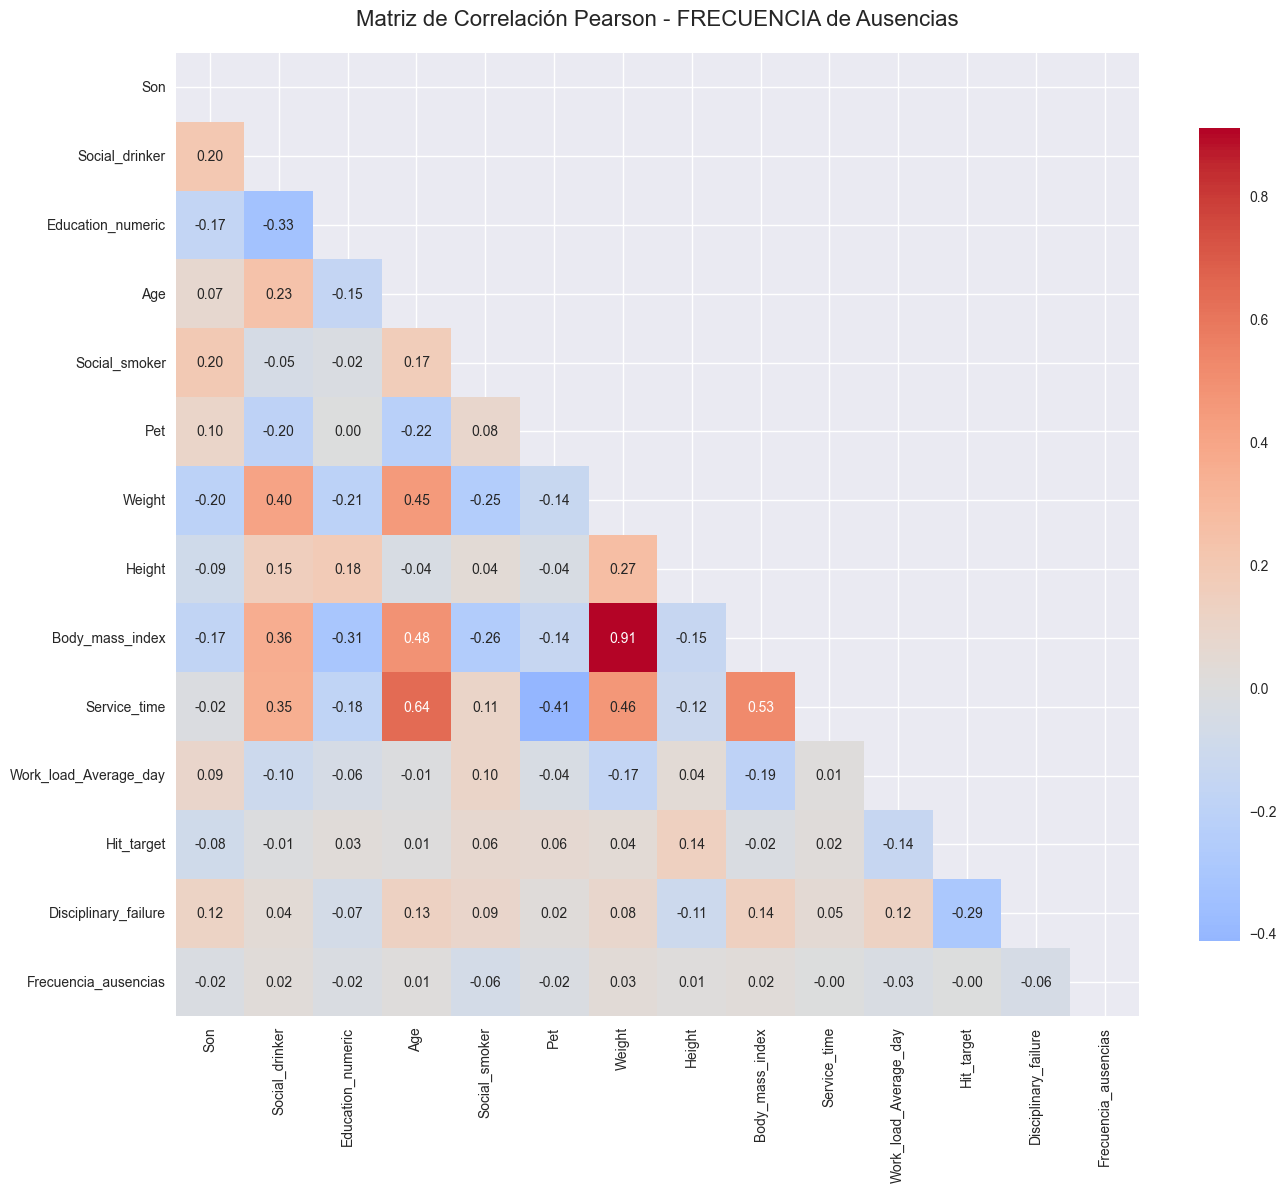

In [125]:
# Matriz de correlación para FRECUENCIA
todas_variables = variables_personales + variables_laborales + [target_variable]

corr_spearman_freq = frecuencia_ausencias[todas_variables].corr(method='pearson')

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_spearman_freq, dtype=bool))
sns.heatmap(corr_spearman_freq, mask=mask, annot=True, cmap='coolwarm', center=0,
           square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación Pearson - FRECUENCIA de Ausencias', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

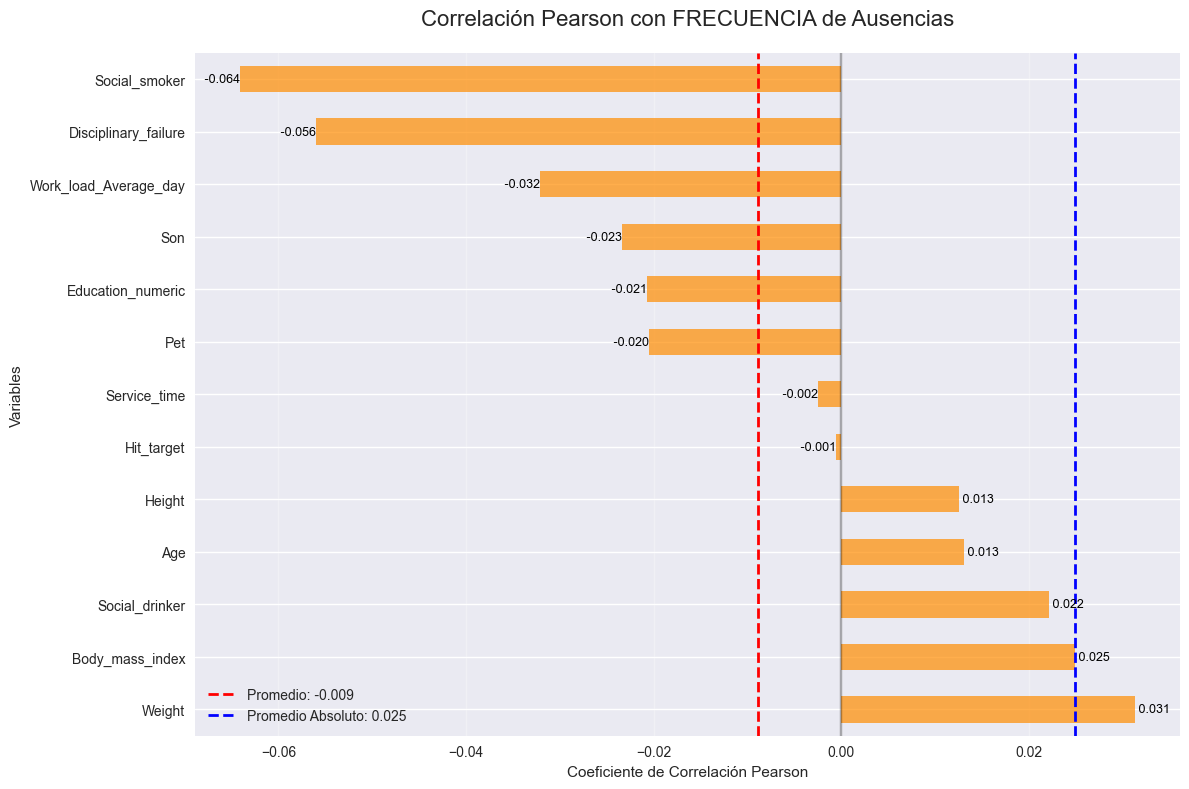

Top variables correlacionadas con FRECUENCIA (Pearson):
Weight               0.031373
Body_mass_index      0.024975
Social_drinker       0.022175
Age                  0.013090
Height               0.012623
Hit_target          -0.000506
Service_time        -0.002471
Pet                 -0.020476
Education_numeric   -0.020732
Son                 -0.023355
dtype: float64


In [126]:
# Correlaciones con la FRECUENCIA usando Pearson
correlaciones_frecuencia = frecuencia_ausencias[todas_variables].corrwith(
    frecuencia_ausencias['Frecuencia_ausencias'], method='pearson')
correlaciones_frecuencia = correlaciones_frecuencia.drop('Frecuencia_ausencias').sort_values(ascending=False)

# Calcular promedios
promedio_pearson = correlaciones_frecuencia.mean()
promedio_absoluto_pearson = correlaciones_frecuencia.abs().mean()

plt.figure(figsize=(12, 8))
bars = correlaciones_frecuencia.plot(kind='barh', color='darkorange', alpha=0.7)

plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=promedio_pearson, color='red', linestyle='--', linewidth=2, 
            label=f'Promedio: {promedio_pearson:.3f}')
plt.axvline(x=promedio_absoluto_pearson, color='blue', linestyle='--', linewidth=2, 
            label=f'Promedio Absoluto: {promedio_absoluto_pearson:.3f}')

plt.title('Correlación Pearson con FRECUENCIA de Ausencias', fontsize=16, pad=20)
plt.xlabel('Coeficiente de Correlación Pearson')  # CORREGIDO
plt.ylabel('Variables')
plt.grid(axis='x', alpha=0.3)
plt.legend()

# Añadir valores en las barras
for i, (valor, variable) in enumerate(zip(correlaciones_frecuencia.values, correlaciones_frecuencia.index)):
    color = 'black' if abs(valor) < 0.3 else 'red' if abs(valor) < 0.7 else 'darkred'
    weight = 'normal' if abs(valor) < 0.3 else 'bold' if abs(valor) < 0.7 else 'bold'
    plt.text(valor, i, f' {valor:.3f}', va='center', ha='left' if valor >= 0 else 'right', 
             color=color, fontweight=weight, fontsize=9)

plt.tight_layout()
plt.show()

print("Top variables correlacionadas con FRECUENCIA (Pearson):")
print(correlaciones_frecuencia.head(10))

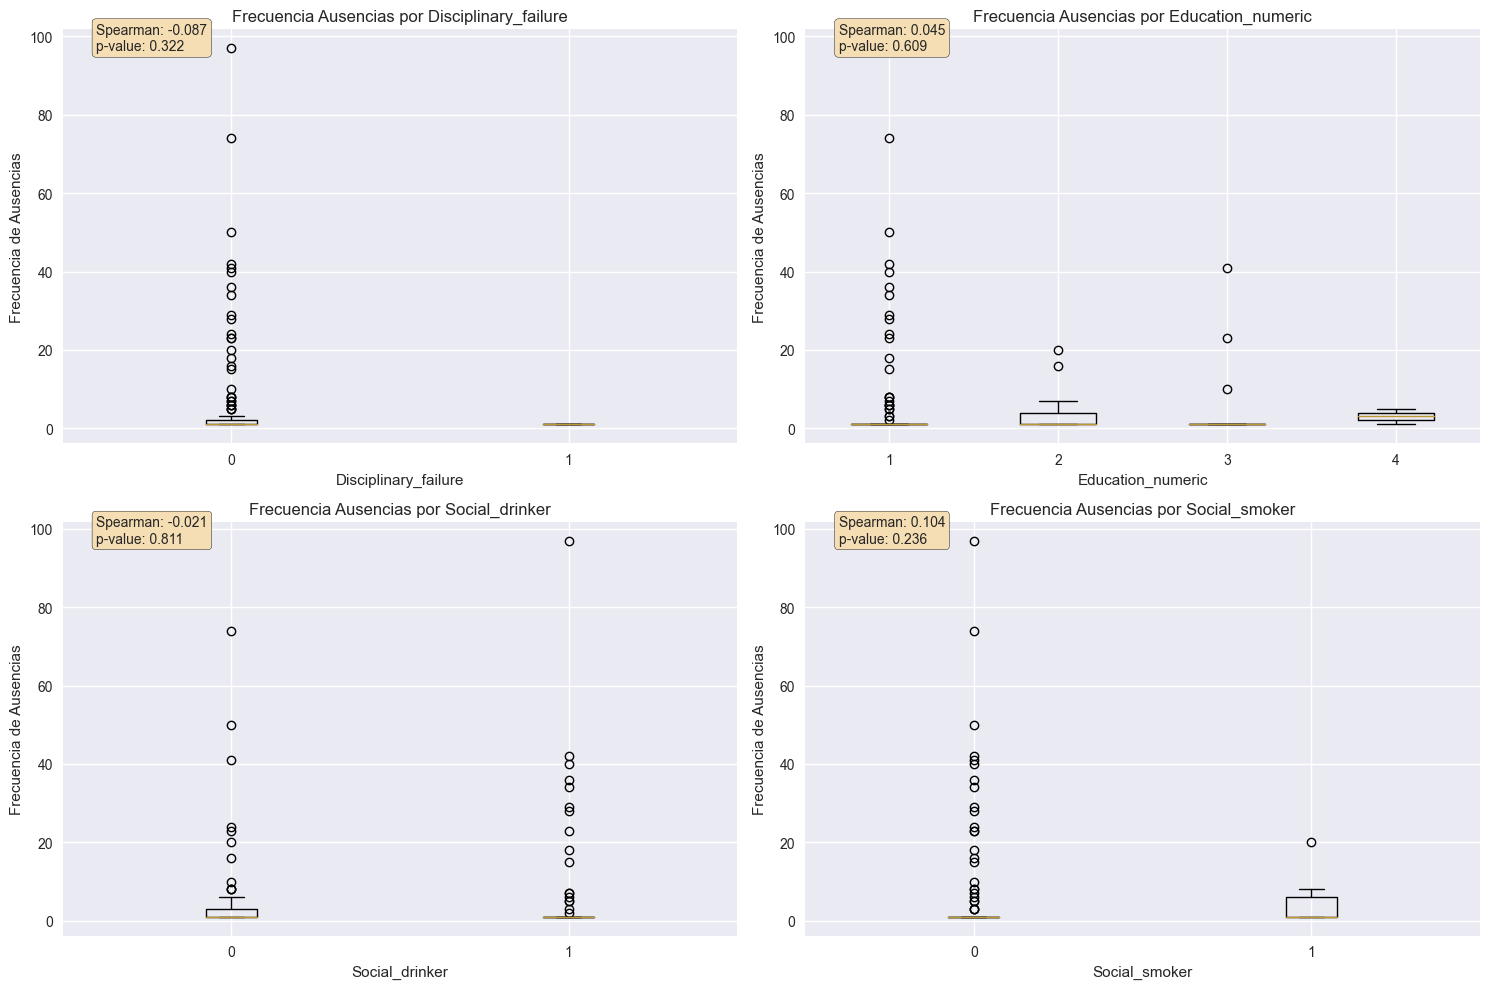

In [127]:
# Variables categóricas para frecuencia
categorical_vars = ['Disciplinary_failure', 'Education_numeric', 'Social_drinker', 'Social_smoker']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(categorical_vars):
    data_to_plot = []
    categories = sorted(frecuencia_ausencias[var].unique())
    
    for category in categories:
        data_to_plot.append(frecuencia_ausencias[frecuencia_ausencias[var] == category]['Frecuencia_ausencias'])
    
    axes[i].boxplot(data_to_plot, labels=categories)
    axes[i].set_title(f'Frecuencia Ausencias por {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia de Ausencias')
    
    # Correlación Spearman
    corr, p_value = spearmanr(frecuencia_ausencias[var], frecuencia_ausencias['Frecuencia_ausencias'])
    axes[i].text(0.05, 0.95, f'Spearman: {corr:.3f}\np-value: {p_value:.3f}', 
                transform=axes[i].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))

plt.tight_layout()
plt.show()

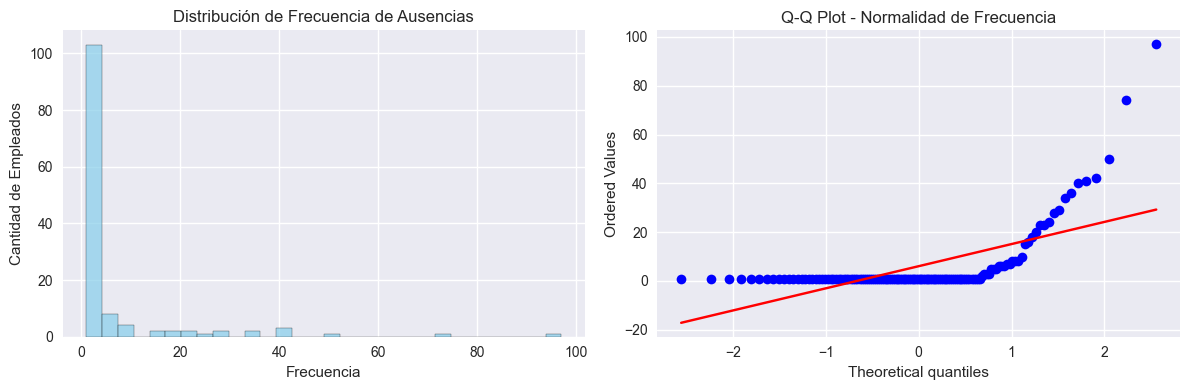

Test de Shapiro-Wilk para normalidad:
Estadístico: 0.4265, p-value: 0.0000
¿Distribución normal? NO


In [128]:
# Verificar la distribución de la frecuencia de ausencias
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(frecuencia_ausencias['Frecuencia_ausencias'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de Frecuencia de Ausencias')
plt.xlabel('Frecuencia')
plt.ylabel('Cantidad de Empleados')

plt.subplot(1, 2, 2)
from scipy import stats
stats.probplot(frecuencia_ausencias['Frecuencia_ausencias'], dist="norm", plot=plt)
plt.title('Q-Q Plot - Normalidad de Frecuencia')

plt.tight_layout()
plt.show()

# Test de normalidad
from scipy.stats import shapiro
stat, p_value = shapiro(frecuencia_ausencias['Frecuencia_ausencias'])
print(f"Test de Shapiro-Wilk para normalidad:")
print(f"Estadístico: {stat:.4f}, p-value: {p_value:.4f}")
print(f"¿Distribución normal? {'SÍ' if p_value > 0.05 else 'NO'}")

In [129]:
print("🔍 INTERPRETACIÓN DE CORRELACIONES PEARSON:")
print("="*60)

# Clasificar correlaciones
fuertes = correlaciones_frecuencia[correlaciones_frecuencia.abs() >= 0.5]
moderadas = correlaciones_frecuencia[(correlaciones_frecuencia.abs() >= 0.3) & (correlaciones_frecuencia.abs() < 0.5)]
debil = correlaciones_frecuencia[(correlaciones_frecuencia.abs() >= 0.1) & (correlaciones_frecuencia.abs() < 0.3)]
muy_debil = correlaciones_frecuencia[correlaciones_frecuencia.abs() < 0.1]

print(f"Correlaciones FUERTES (|r| ≥ 0.5): {len(fuertes)}")
for var, corr in fuertes.items():
    direccion = "positiva" if corr > 0 else "negativa"
    print(f"  • {var}: {corr:.3f} ({direccion})")

print(f"\nCorrelaciones MODERADAS (0.3 ≤ |r| < 0.5): {len(moderadas)}")
for var, corr in moderadas.items():
    direccion = "positiva" if corr > 0 else "negativa"
    print(f"  • {var}: {corr:.3f} ({direccion})")

print(f"\nCorrelaciones DÉBILES (0.1 ≤ |r| < 0.3): {len(debil)}")
for var, corr in debil.items():
    direccion = "positiva" if corr > 0 else "negativa"
    print(f"  • {var}: {corr:.3f} ({direccion})")

print(f"\nCorrelaciones MUY DÉBILES (|r| < 0.1): {len(muy_debil)}")

print(f"\n📊 RESUMEN ESTADÍSTICO PEARSON:")
print(f"• Promedio de correlaciones: {promedio_pearson:.4f}")
print(f"• Fuerza promedio (absoluto): {promedio_absoluto_pearson:.4f}")
print(f"• Correlación máxima: {correlaciones_frecuencia.max():.4f}")
print(f"• Correlación mínima: {correlaciones_frecuencia.min():.4f}")

🔍 INTERPRETACIÓN DE CORRELACIONES PEARSON:
Correlaciones FUERTES (|r| ≥ 0.5): 0

Correlaciones MODERADAS (0.3 ≤ |r| < 0.5): 0

Correlaciones DÉBILES (0.1 ≤ |r| < 0.3): 0

Correlaciones MUY DÉBILES (|r| < 0.1): 13

📊 RESUMEN ESTADÍSTICO PEARSON:
• Promedio de correlaciones: -0.0089
• Fuerza promedio (absoluto): 0.0249
• Correlación máxima: 0.0314
• Correlación mínima: -0.0641


In [131]:
# Análisis profundo de la distribución
print("📊 ANÁLISIS DETALLADO DE LA DISTRIBUCIÓN DE FRECUENCIA:")
print("="*50)

# Estadísticas descriptivas
print("Estadísticas descriptivas de Frecuencia_ausencias:")
print(f"• Media: {frecuencia_ausencias['Frecuencia_ausencias'].mean():.2f}")
print(f"• Mediana: {frecuencia_ausencias['Frecuencia_ausencias'].median():.2f}")
print(f"• Moda: {frecuencia_ausencias['Frecuencia_ausencias'].mode().values[0]}")
print(f"• Asimetría: {frecuencia_ausencias['Frecuencia_ausencias'].skew():.2f}")
print(f"• Curtosis: {frecuencia_ausencias['Frecuencia_ausencias'].kurtosis():.2f}")

# Identificar outliers
Q1 = frecuencia_ausencias['Frecuencia_ausencias'].quantile(0.25)
Q3 = frecuencia_ausencias['Frecuencia_ausencias'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = frecuencia_ausencias[frecuencia_ausencias['Frecuencia_ausencias'] > limite_superior]
print(f"\n🔍 ANÁLISIS DE OUTLIERS:")
print(f"• Límite superior para outliers: {limite_superior:.2f}")
print(f"• Número de outliers: {len(outliers)}")
print(f"• Porcentaje de outliers: {len(outliers)/len(frecuencia_ausencias)*100:.1f}%")

if len(outliers) > 0:
    print(f"• Valores outlier: {sorted(outliers['Frecuencia_ausencias'].unique())}")

📊 ANÁLISIS DETALLADO DE LA DISTRIBUCIÓN DE FRECUENCIA:
Estadísticas descriptivas de Frecuencia_ausencias:
• Media: 6.07
• Mediana: 1.00
• Moda: 1
• Asimetría: 3.95
• Curtosis: 18.59

🔍 ANÁLISIS DE OUTLIERS:
• Límite superior para outliers: 1.62
• Número de outliers: 33
• Porcentaje de outliers: 25.0%
• Valores outlier: [2, 3, 5, 6, 7, 8, 10, 15, 16, 18, 20, 23, 24, 28, 29, 34, 36, 40, 41, 42, 50, 74, 97]


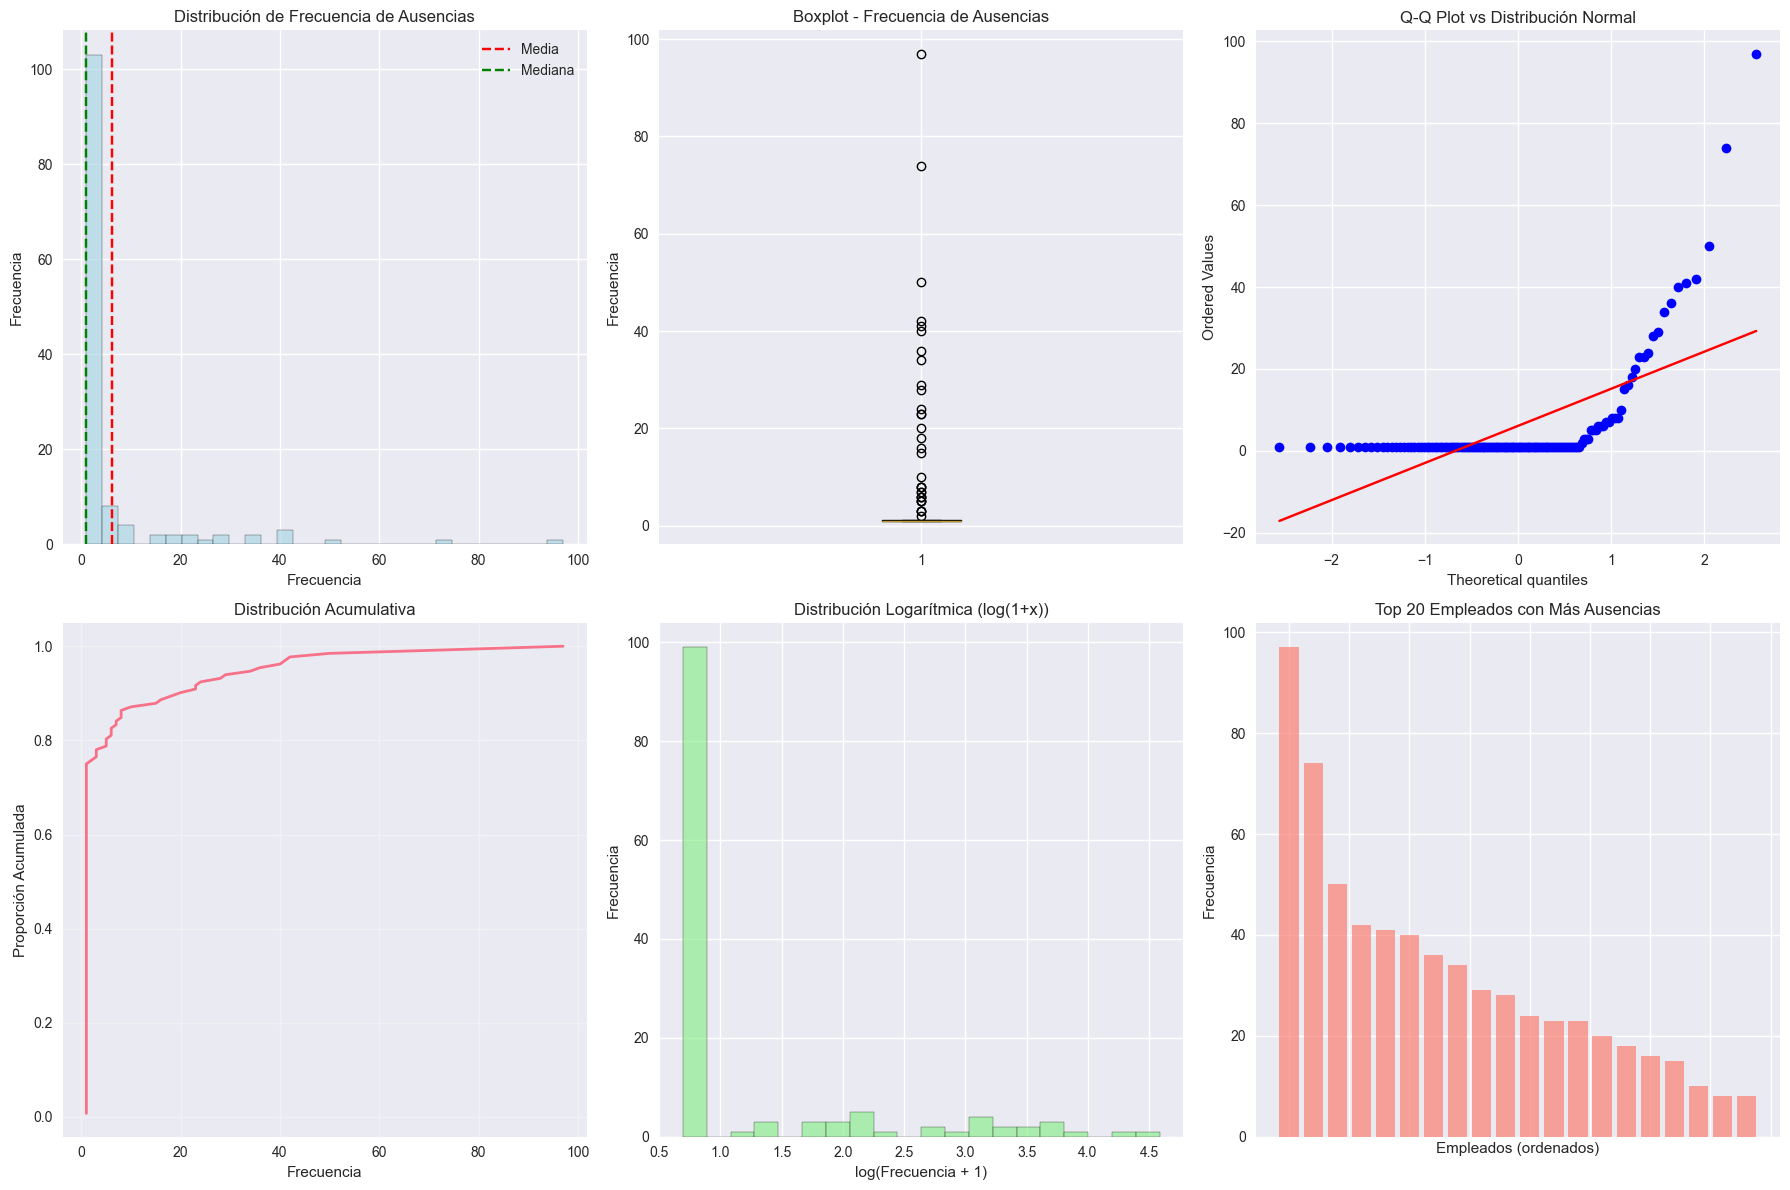

In [132]:
# Visualización completa de la distribución
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Histograma
axes[0,0].hist(frecuencia_ausencias['Frecuencia_ausencias'], bins=30, color='lightblue', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribución de Frecuencia de Ausencias')
axes[0,0].set_xlabel('Frecuencia')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].axvline(frecuencia_ausencias['Frecuencia_ausencias'].mean(), color='red', linestyle='--', label='Media')
axes[0,0].axvline(frecuencia_ausencias['Frecuencia_ausencias'].median(), color='green', linestyle='--', label='Mediana')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(frecuencia_ausencias['Frecuencia_ausencias'])
axes[0,1].set_title('Boxplot - Frecuencia de Ausencias')
axes[0,1].set_ylabel('Frecuencia')

# 3. Q-Q Plot
from scipy import stats
stats.probplot(frecuencia_ausencias['Frecuencia_ausencias'], dist="norm", plot=axes[0,2])
axes[0,2].set_title('Q-Q Plot vs Distribución Normal')

# 4. Distribución acumulativa
sorted_data = np.sort(frecuencia_ausencias['Frecuencia_ausencias'])
yvals = np.arange(1, len(sorted_data)+1) / len(sorted_data)
axes[1,0].plot(sorted_data, yvals, linewidth=2)
axes[1,0].set_title('Distribución Acumulativa')
axes[1,0].set_xlabel('Frecuencia')
axes[1,0].set_ylabel('Proporción Acumulada')
axes[1,0].grid(True, alpha=0.3)

# 5. Distribución logarítmica (para ver si es log-normal)
frecuencia_log = np.log1p(frecuencia_ausencias['Frecuencia_ausencias'])  # log(1+x) para evitar log(0)
axes[1,1].hist(frecuencia_log, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1,1].set_title('Distribución Logarítmica (log(1+x))')
axes[1,1].set_xlabel('log(Frecuencia + 1)')
axes[1,1].set_ylabel('Frecuencia')

# 6. Top 20 empleados con más ausencias
top_20 = frecuencia_ausencias.nlargest(20, 'Frecuencia_ausencias')
axes[1,2].bar(range(len(top_20)), top_20['Frecuencia_ausencias'], color='salmon', alpha=0.7)
axes[1,2].set_title('Top 20 Empleados con Más Ausencias')
axes[1,2].set_xlabel('Empleados (ordenados)')
axes[1,2].set_ylabel('Frecuencia')
axes[1,2].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

🛡️ ANÁLISIS ROBUSTO - CON Y SIN OUTLIERS
Datos originales: 132 empleados
Datos sin outliers: 99 empleados
Outliers eliminados: 33 empleados


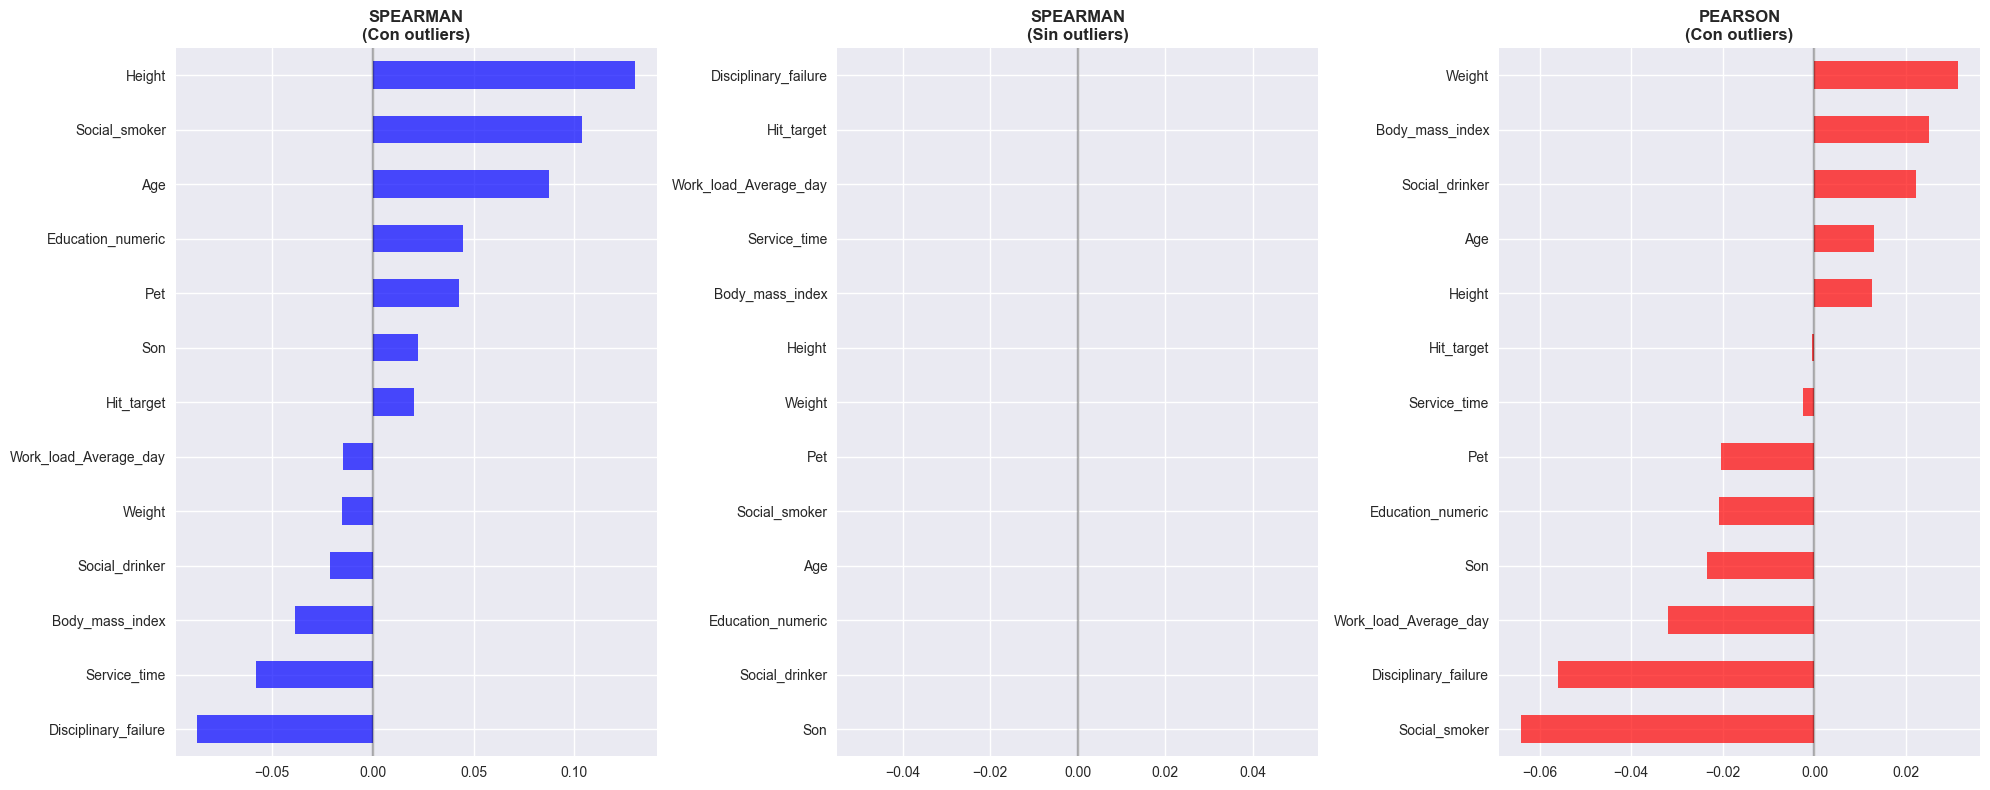

In [135]:
# Calcular correlaciones Spearman para comparar
correlaciones_spearman = frecuencia_ausencias[todas_variables].corrwith(
    frecuencia_ausencias['Frecuencia_ausencias'], method='spearman')
correlaciones_spearman = correlaciones_spearman.drop('Frecuencia_ausencias')

# ANÁLISIS ROBUSTO: Con y sin outliers
print("🛡️ ANÁLISIS ROBUSTO - CON Y SIN OUTLIERS")
print("="*50)

# Identificar outliers
Q1 = frecuencia_ausencias['Frecuencia_ausencias'].quantile(0.25)
Q3 = frecuencia_ausencias['Frecuencia_ausencias'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = frecuencia_ausencias[frecuencia_ausencias['Frecuencia_ausencias'] > limite_superior]
frecuencia_sin_outliers = frecuencia_ausencias[frecuencia_ausencias['Frecuencia_ausencias'] <= limite_superior]

print(f"Datos originales: {len(frecuencia_ausencias)} empleados")
print(f"Datos sin outliers: {len(frecuencia_sin_outliers)} empleados")
print(f"Outliers eliminados: {len(outliers)} empleados")

# Correlaciones sin outliers (Spearman)
correlaciones_sin_outliers = frecuencia_sin_outliers[todas_variables].corrwith(
    frecuencia_sin_outliers['Frecuencia_ausencias'], method='spearman')
correlaciones_sin_outliers = correlaciones_sin_outliers.drop('Frecuencia_ausencias').sort_values(ascending=False)

# Comparación
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))

# Con outliers (Spearman)
correlaciones_spearman.sort_values().plot(kind='barh', ax=ax1, color='blue', alpha=0.7)
ax1.set_title('SPEARMAN\n(Con outliers)', fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Sin outliers (Spearman)
correlaciones_sin_outliers.sort_values().plot(kind='barh', ax=ax2, color='green', alpha=0.7)
ax2.set_title('SPEARMAN\n(Sin outliers)', fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Pearson (Con outliers)
correlaciones_frecuencia.sort_values().plot(kind='barh', ax=ax3, color='red', alpha=0.7)
ax3.set_title('PEARSON\n(Con outliers)', fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

In [136]:
# Crear DataFrame comparativo completo
df_comparacion_completo = pd.DataFrame({
    'Pearson': correlaciones_frecuencia,
    'Spearman_Con_Outliers': correlaciones_spearman,
    'Spearman_Sin_Outliers': correlaciones_sin_outliers,
    'Diferencia_Pearson_Spearman': correlaciones_frecuencia - correlaciones_spearman,
    'Diferencia_Spearman_Con_Sin': correlaciones_spearman - correlaciones_sin_outliers
}).sort_values('Diferencia_Pearson_Spearman', key=abs, ascending=False)

print("📊 COMPARACIÓN COMPLETA ENTRE MÉTODOS:")
print("="*60)
print(df_comparacion_completo.head(10))

# Estadísticas de las diferencias
print(f"\n📈 ESTADÍSTICAS DE LAS DIFERENCIAS:")
print(f"• Diferencia máxima Pearson-Spearman: {df_comparacion_completo['Diferencia_Pearson_Spearman'].abs().max():.3f}")
print(f"• Diferencia promedio Pearson-Spearman: {df_comparacion_completo['Diferencia_Pearson_Spearman'].abs().mean():.3f}")
print(f"• Variables con diferencia > 0.2: {sum(df_comparacion_completo['Diferencia_Pearson_Spearman'].abs() > 0.2)}")

📊 COMPARACIÓN COMPLETA ENTRE MÉTODOS:
                    Pearson  Spearman_Con_Outliers  Spearman_Sin_Outliers  \
Social_smoker     -0.064113               0.103826                    NaN   
Height             0.012623               0.129937                    NaN   
Age                0.013090               0.087510                    NaN   
Education_numeric -0.020732               0.044968                    NaN   
Body_mass_index    0.024975              -0.038479                    NaN   
Pet               -0.020476               0.042630                    NaN   
Service_time      -0.002471              -0.057717                    NaN   
Weight             0.031373              -0.015059                    NaN   
Son               -0.023355               0.022699                    NaN   
Social_drinker     0.022175              -0.020979                    NaN   

                   Diferencia_Pearson_Spearman  Diferencia_Spearman_Con_Sin  
Social_smoker                       

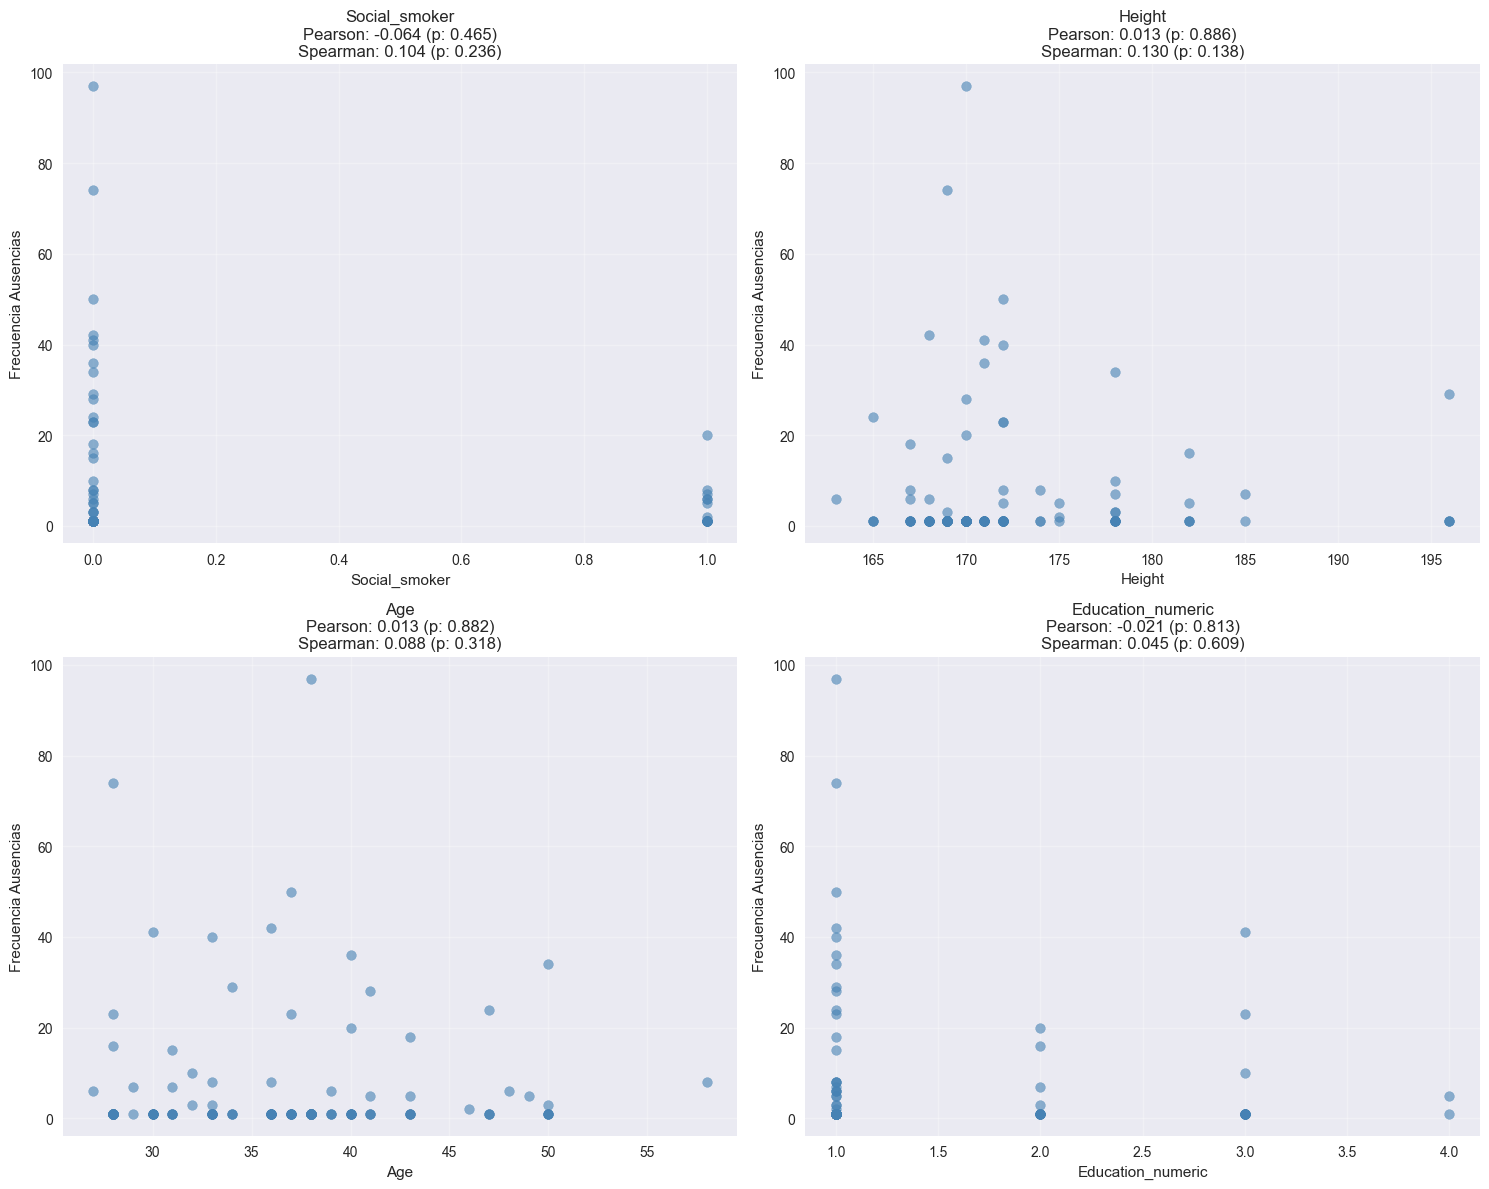

In [137]:
# Identificar variables con mayores diferencias entre Pearson y Spearman
variables_con_diferencias = df_comparacion_completo['Diferencia_Pearson_Spearman'].abs().nlargest(4).index.tolist()

if variables_con_diferencias:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    for i, var in enumerate(variables_con_diferencias):
        if i < 4:
            # Scatter plot
            axes[i].scatter(frecuencia_ausencias[var], frecuencia_ausencias['Frecuencia_ausencias'], 
                           alpha=0.6, color='steelblue')
            axes[i].set_xlabel(var)
            axes[i].set_ylabel('Frecuencia Ausencias')
            
            # Calcular ambas correlaciones para esta variable específica
            pearson_val, pearson_p = pearsonr(frecuencia_ausencias[var], frecuencia_ausencias['Frecuencia_ausencias'])
            spearman_val, spearman_p = spearmanr(frecuencia_ausencias[var], frecuencia_ausencias['Frecuencia_ausencias'])
            
            axes[i].set_title(f'{var}\nPearson: {pearson_val:.3f} (p: {pearson_p:.3f})\nSpearman: {spearman_val:.3f} (p: {spearman_p:.3f})')
            axes[i].grid(True, alpha=0.3)
    
    # Ocultar ejes vacíos si hay menos de 4 variables
    for i in range(len(variables_con_diferencias), 4):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [139]:
print("🎯 RECOMENDACIÓN FINAL BASADA EN EL ANÁLISIS:")
print("="*50)

# Evaluar el impacto de los outliers
impacto_outliers = (correlaciones_spearman - correlaciones_sin_outliers).abs().mean()
print(f"• Impacto promedio de outliers en Spearman: {impacto_outliers:.3f}")

# Evaluar diferencias entre métodos
dif_pearson_spearman = (correlaciones_frecuencia - correlaciones_spearman).abs().mean()
print(f"• Diferencia promedio Pearson-Spearman: {dif_pearson_spearman:.3f}")

if impacto_outliers > 0.1:
    print("🔴 ALTO impacto de outliers - Considera usar Spearman sin outliers")
elif dif_pearson_spearman > 0.15:
    print("🟡 MEDIO impacto - Investiga las variables con mayores diferencias")
else:
    print("🟢 BAJO impacto - Pearson puede ser aceptable")

print(f"\n💡 DECISIÓN FINAL:")
if dif_pearson_spearman < 0.1:
    print("→ Usa PEARSON: Las diferencias son mínimas y es más interpretable")
else:
    print("→ Usa SPEARMAN: Es más robusto para datos no normales")
    print("→ O considera análisis sin outliers")

print(f"\n📋 VARIABLES MÁS AFECTADAS POR LA ELECCIÓN DEL MÉTODO:")
variables_problematicas = df_comparacion_completo[df_comparacion_completo['Diferencia_Pearson_Spearman'].abs() > 0.2]
for var, row in variables_problematicas.iterrows():
    print(f"  • {var}: Pearson={row['Pearson']:.3f}, Spearman={row['Spearman_Con_Outliers']:.3f}, Diff={row['Diferencia_Pearson_Spearman']:.3f}")

🎯 RECOMENDACIÓN FINAL BASADA EN EL ANÁLISIS:
• Impacto promedio de outliers en Spearman: nan
• Diferencia promedio Pearson-Spearman: 0.062
🟢 BAJO impacto - Pearson puede ser aceptable

💡 DECISIÓN FINAL:
→ Usa PEARSON: Las diferencias son mínimas y es más interpretable

📋 VARIABLES MÁS AFECTADAS POR LA ELECCIÓN DEL MÉTODO:


In [ ]:
# Crear categorías de frecuencia
bins = [0, 1, 3, 5, 10, 100]
labels = ['Muy Baja (0-1)', 'Baja (2-3)', 'Media (4-5)', 'Alta (6-10)', 'Muy Alta (>10)']
frecuencia_ausencias['Categoria_Frecuencia'] = pd.cut(frecuencia_ausencias['Frecuencia_ausencias'], 
                                                     bins=bins, labels=labels, right=True)

# Análisis por categorías
categoria_stats = frecuencia_ausencias.groupby('Categoria_Frecuencia').agg({
    'Frecuencia_ausencias': 'count',
    'Age': 'mean',
    'Service_time': 'mean',
    'Transportation_expense': 'mean',
    'Disciplinary_failure': 'mean'
}).rename(columns={'Frecuencia_ausencias': 'Cantidad_Empleados'})

print("\nESTADÍSTICAS POR CATEGORÍA DE FRECUENCIA:")
print("="*60)
print(categoria_stats)


ESTADÍSTICAS POR CATEGORÍA DE FRECUENCIA:
                      Cantidad_Empleados        Age  Service_time  \
Categoria_Frecuencia                                                
Muy Baja (0-1)                        99  35.616162     12.626263   
Baja (2-3)                             4  40.250000     13.250000   
Media (4-5)                            3  44.333333     19.000000   
Alta (6-10)                            9  37.000000      9.777778   
Muy Alta (>10)                        17  36.529412     12.176471   

                      Transportation_expense  Disciplinary_failure  
Categoria_Frecuencia                                                
Muy Baja (0-1)                    223.101010              0.030303  
Baja (2-3)                        266.250000              0.000000  
Media (4-5)                       271.333333              0.000000  
Alta (6-10)                       235.333333              0.000000  
Muy Alta (>10)                    236.294118              0

In [ ]:
# Dividir en grupos: alta frecuencia vs baja frecuencia
mediana = frecuencia_ausencias['Frecuencia_ausencias'].median()
alta_frecuencia = frecuencia_ausencias[frecuencia_ausencias['Frecuencia_ausencias'] > mediana]
baja_frecuencia = frecuencia_ausencias[frecuencia_ausencias['Frecuencia_ausencias'] <= mediana]

print(f"\nCOMPARACIÓN ENTRE GRUPOS (Mediana = {mediana} ausencias):")
print("="*50)
print(f"Empleados con baja frecuencia: {len(baja_frecuencia)}")
print(f"Empleados con alta frecuencia: {len(alta_frecuencia)}")

# Comparar medias de variables significativas
variables_comparar = significativas_frecuencia['Variable'].head(5).tolist()

comparacion_grupos = pd.DataFrame({
    'Variable': variables_comparar,
    'Baja_Frecuencia_Media': [baja_frecuencia[var].mean() for var in variables_comparar],
    'Alta_Frecuencia_Media': [alta_frecuencia[var].mean() for var in variables_comparar],
    'Diferencia': [alta_frecuencia[var].mean() - baja_frecuencia[var].mean() for var in variables_comparar]
})

print("\nComparación de medias entre grupos:")
print(comparacion_grupos.to_string(index=False))


COMPARACIÓN ENTRE GRUPOS (Mediana = 1.0 ausencias):
Empleados con baja frecuencia: 99
Empleados con alta frecuencia: 33

Comparación de medias entre grupos:
Empty DataFrame
Columns: [Variable, Baja_Frecuencia_Media, Alta_Frecuencia_Media, Diferencia]
Index: []


In [ ]:
print("\n" + "="*80)
print("RESUMEN EJECUTIVO - ANÁLISIS DE FRECUENCIA DE AUSENCIAS")
print("="*80)

print(f"\n📊 DATOS GENERALES:")
print(f"   • Total de empleados analizados: {len(frecuencia_ausencias)}")
print(f"   • Total de ausencias registradas: {frecuencia_ausencias['Frecuencia_ausencias'].sum()}")
print(f"   • Rango de ausencias por empleado: {frecuencia_ausencias['Frecuencia_ausencias'].min()} - {frecuencia_ausencias['Frecuencia_ausencias'].max()}")
print(f"   • Mediana de ausencias por empleado: {mediana}")

print(f"\n🔍 VARIABLES MÁS IMPORTANTES:")
for idx, row in significativas_frecuencia.head(5).iterrows():
    direccion = "positiva" if row['Spearman_Corr'] > 0 else "negativa"
    print(f"   • {row['Variable']} ({row['Tipo']}): {row['Spearman_Corr']:.3f} ({direccion}) - {row['Fuerza_Spearman']}")

print(f"\n💡 RECOMENDACIONES:")
if len(significativas_frecuencia) > 0:
    top_var = significativas_frecuencia.iloc[0]
    print(f"   • Enfocar intervenciones en: {top_var['Variable']}")
    print(f"   • Variables significativas encontradas: {len(significativas_frecuencia)}")
else:
    print("   • No se encontraron correlaciones significativas fuertes")

print("="*80)


RESUMEN EJECUTIVO - ANÁLISIS DE FRECUENCIA DE AUSENCIAS

📊 DATOS GENERALES:
   • Total de empleados analizados: 132
   • Total de ausencias registradas: 801
   • Rango de ausencias por empleado: 1 - 97
   • Mediana de ausencias por empleado: 1.0

🔍 VARIABLES MÁS IMPORTANTES:

💡 RECOMENDACIONES:
   • No se encontraron correlaciones significativas fuertes


#regresion lineal


In [143]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm

# Definir variables para el modelo
variables_modelo = ['Son', 'Social_drinker', 'Height', 'Disciplinary_failure']
variable_objetivo = 'Frecuencia_ausencias'

print("🔧 PREPARANDO MODELO DE REGRESIÓN LINEAL")
print("="*50)
print(f"Variables predictoras: {variables_modelo}")
print(f"Variable objetivo: {variable_objetivo}")
print(f"Tamaño del dataset: {len(frecuencia_ausencias)} empleados")

# Preparar datos
X = frecuencia_ausencias[variables_modelo]
y = frecuencia_ausencias[variable_objetivo]

# Dividir en train y test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n📊 DIVISIÓN DE DATOS:")
print(f"• Conjunto de entrenamiento: {len(X_train)} empleados")
print(f"• Conjunto de prueba: {len(X_test)} empleados")

🔧 PREPARANDO MODELO DE REGRESIÓN LINEAL
Variables predictoras: ['Son', 'Social_drinker', 'Height', 'Disciplinary_failure']
Variable objetivo: Frecuencia_ausencias
Tamaño del dataset: 132 empleados

📊 DIVISIÓN DE DATOS:
• Conjunto de entrenamiento: 105 empleados
• Conjunto de prueba: 27 empleados


In [144]:
# Crear y entrenar el modelo
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Predecir
y_pred = modelo_lr.predict(X_test)

# Métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📈 RESULTADOS DEL MODELO (scikit-learn)")
print("="*40)
print(f"• R² (Coeficiente de determinación): {r2:.4f}")
print(f"• RMSE (Raíz del error cuadrático medio): {rmse:.4f}")
print(f"• MAE (Error absoluto medio): {mae:.4f}")

# Coeficientes del modelo
print(f"\n🔍 COEFICIENTES DEL MODELO:")
for i, coef in enumerate(modelo_lr.coef_):
    print(f"  • {variables_modelo[i]}: {coef:.4f}")
print(f"  • Intercepto: {modelo_lr.intercept_:.4f}")


📈 RESULTADOS DEL MODELO (scikit-learn)
• R² (Coeficiente de determinación): -0.0853
• RMSE (Raíz del error cuadrático medio): 16.4962
• MAE (Error absoluto medio): 8.3400

🔍 COEFICIENTES DEL MODELO:
  • Son: -1.3095
  • Social_drinker: 1.9777
  • Height: 0.0805
  • Disciplinary_failure: -3.0504
  • Intercepto: -7.7983


In [145]:
# Modelo con statsmodels (proporciona más detalles estadísticos)
X_sm = sm.add_constant(X)  # Añadir intercepto
modelo_sm = sm.OLS(y, X_sm)
resultado_sm = modelo_sm.fit()

print("\n📊 RESULTADOS DETALLADOS (statsmodels)")
print("="*45)
print(resultado_sm.summary())


📊 RESULTADOS DETALLADOS (statsmodels)
                             OLS Regression Results                             
Dep. Variable:     Frecuencia_ausencias   R-squared:                       0.004
Model:                              OLS   Adj. R-squared:                 -0.027
Method:                   Least Squares   F-statistic:                    0.1344
Date:                  Mon, 29 Sep 2025   Prob (F-statistic):              0.969
Time:                          15:05:23   Log-Likelihood:                -533.61
No. Observations:                   132   AIC:                             1077.
Df Residuals:                       127   BIC:                             1092.
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

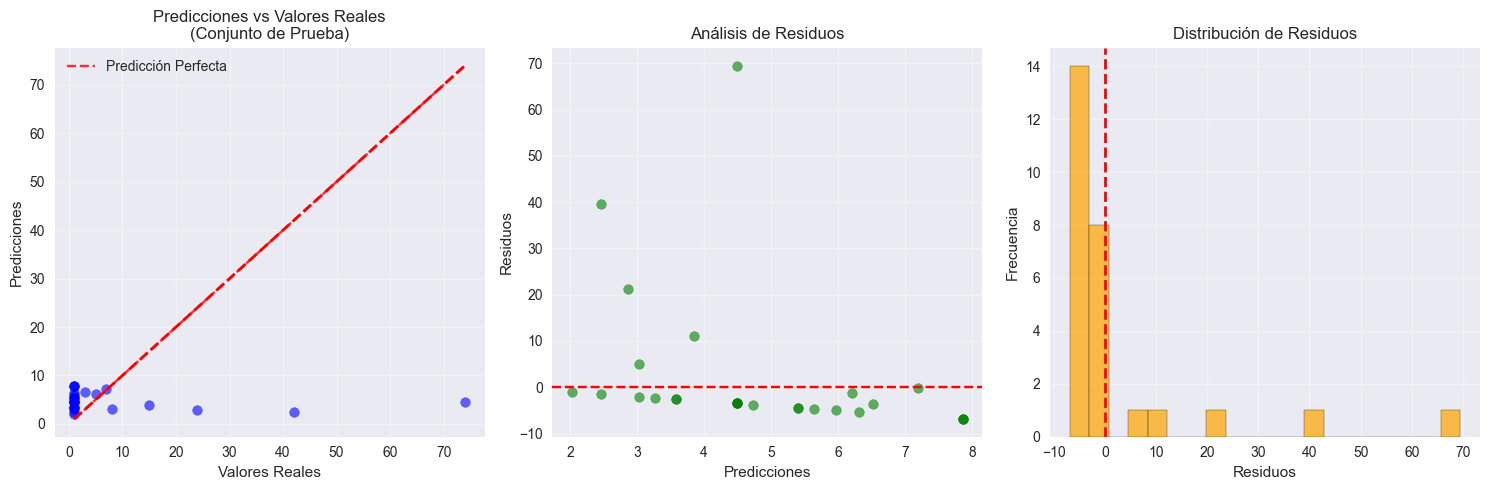

In [146]:
# Visualización de predicciones vs valores reales
plt.figure(figsize=(15, 5))

# Gráfico 1: Predicciones vs Reales
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales\n(Conjunto de Prueba)')
plt.grid(alpha=0.3)

# Añadir línea de perfecta predicción
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, 'r--', alpha=0.8, label='Predicción Perfecta')
plt.legend()

# Gráfico 2: Residuos
plt.subplot(1, 3, 2)
residuos = y_test - y_pred
plt.scatter(y_pred, residuos, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Análisis de Residuos')
plt.grid(alpha=0.3)

# Gráfico 3: Distribución de residuos
plt.subplot(1, 3, 3)
plt.hist(residuos, bins=20, color='orange', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [147]:
# Diagnóstico del modelo
print("\n🔍 DIAGNÓSTICO DEL MODELO")
print("="*35)

# Validación de supuestos
from scipy.stats import shapiro, normaltest

# 1. Normalidad de residuos
stat_shapiro, p_shapiro = shapiro(residuos)
stat_norm, p_norm = normaltest(residuos)

print(f"1. NORMALIDAD DE RESIDUOS:")
print(f"   • Shapiro-Wilk: p-value = {p_shapiro:.4f} → {'Normal' if p_shapiro > 0.05 else 'NO Normal'}")
print(f"   • Test de Normalidad: p-value = {p_norm:.4f} → {'Normal' if p_norm > 0.05 else 'NO Normal'}")

# 2. Homocedasticidad (usando test de Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(resultado_sm.resid, resultado_sm.model.exog)
print(f"2. HOMOCEDASTICIDAD:")
print(f"   • Breusch-Pagan: p-value = {bp_test[1]:.4f} → {'Homocedástico' if bp_test[1] > 0.05 else 'Heterocedástico'}")

# 3. Multicolinealidad (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(f"3. MULTICOLINEALIDAD (VIF):")
for idx, row in vif_data.iterrows():
    interpretacion = "Baja" if row['VIF'] < 5 else "Moderada" if row['VIF'] < 10 else "Alta"
    print(f"   • {row['Variable']}: VIF = {row['VIF']:.2f} ({interpretacion})")


🔍 DIAGNÓSTICO DEL MODELO
1. NORMALIDAD DE RESIDUOS:
   • Shapiro-Wilk: p-value = 0.0000 → NO Normal
   • Test de Normalidad: p-value = 0.0000 → NO Normal
2. HOMOCEDASTICIDAD:
   • Breusch-Pagan: p-value = 0.8378 → Homocedástico
3. MULTICOLINEALIDAD (VIF):
   • Son: VIF = 2.09 (Baja)
   • Social_drinker: VIF = 2.28 (Baja)
   • Height: VIF = 2.81 (Baja)
   • Disciplinary_failure: VIF = 1.04 (Baja)


In [148]:
# PRIMERO: Agrupar por empleado para calcular HORAS TOTALES de absentismo
horas_ausencias = df_clean.groupby('ID').agg({
    'Absenteeism_hours': 'sum',  # Esto serán las HORAS TOTALES
    'Son': 'first',
    'Social_drinker': 'first', 
    'Education_numeric': 'first',
    'Age': 'first',
    'Social_smoker': 'first',
    'Pet': 'first',
    'Weight': 'first',
    'Height': 'first',
    'Body_mass_index': 'first',
    'Transportation_expense': 'first',
    'Distance_Residence_Work': 'first',
    'Service_time': 'first',
    'Work_load_Average_day': 'first',
    'Hit_target': 'first',
    'Disciplinary_failure': 'first'
}).reset_index()

horas_ausencias = horas_ausencias.rename(columns={'Absenteeism_hours': 'Horas_ausencias_totales'})

print(f"Número de empleados únicos: {len(horas_ausencias)}")
print(f"Horas totales de absentismo por empleado:")
print(horas_ausencias['Horas_ausencias_totales'].describe())

Número de empleados únicos: 132
Horas totales de absentismo por empleado:
count    132.000000
mean      44.363636
std       96.168131
min        0.000000
25%        2.000000
50%        8.000000
75%       24.000000
max      476.000000
Name: Horas_ausencias_totales, dtype: float64


In [149]:
# Crear y entrenar el modelo
modelo_lr_horas = LinearRegression()
modelo_lr_horas.fit(X_train, y_train)

# Predecir
y_pred = modelo_lr_horas.predict(X_test)

# Métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📈 RESULTADOS DEL MODELO - HORAS TOTALES (scikit-learn)")
print("="*50)
print(f"• R² (Coeficiente de determinación): {r2:.4f}")
print(f"• RMSE (Raíz del error cuadrático medio): {rmse:.4f} horas")
print(f"• MAE (Error absoluto medio): {mae:.4f} horas")

# Coeficientes del modelo
print(f"\n🔍 COEFICIENTES DEL MODELO:")
for i, coef in enumerate(modelo_lr_horas.coef_):
    print(f"  • {variables_modelo[i]}: {coef:.4f}")
print(f"  • Intercepto: {modelo_lr_horas.intercept_:.4f}")


📈 RESULTADOS DEL MODELO - HORAS TOTALES (scikit-learn)
• R² (Coeficiente de determinación): -0.0853
• RMSE (Raíz del error cuadrático medio): 16.4962 horas
• MAE (Error absoluto medio): 8.3400 horas

🔍 COEFICIENTES DEL MODELO:
  • Son: -1.3095
  • Social_drinker: 1.9777
  • Height: 0.0805
  • Disciplinary_failure: -3.0504
  • Intercepto: -7.7983


In [150]:
# Modelo con statsmodels (proporciona más detalles estadísticos)
X_sm = sm.add_constant(X)  # Añadir intercepto
modelo_sm_horas = sm.OLS(y, X_sm)
resultado_sm_horas = modelo_sm_horas.fit()

print("\n📊 RESULTADOS DETALLADOS - HORAS TOTALES (statsmodels)")
print("="*55)
print(resultado_sm_horas.summary())


📊 RESULTADOS DETALLADOS - HORAS TOTALES (statsmodels)
                             OLS Regression Results                             
Dep. Variable:     Frecuencia_ausencias   R-squared:                       0.004
Model:                              OLS   Adj. R-squared:                 -0.027
Method:                   Least Squares   F-statistic:                    0.1344
Date:                  Mon, 29 Sep 2025   Prob (F-statistic):              0.969
Time:                          15:08:40   Log-Likelihood:                -533.61
No. Observations:                   132   AIC:                             1077.
Df Residuals:                       127   BIC:                             1092.
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

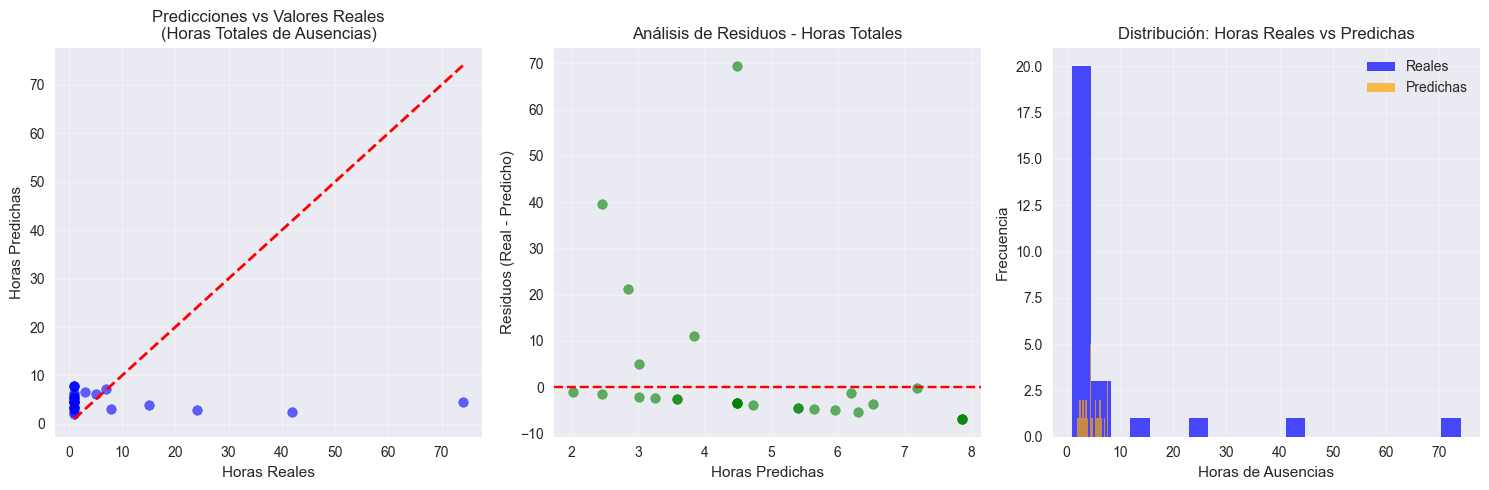

In [151]:
# Visualización de predicciones vs valores reales
plt.figure(figsize=(15, 5))

# Gráfico 1: Predicciones vs Reales
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Horas Reales')
plt.ylabel('Horas Predichas')
plt.title('Predicciones vs Valores Reales\n(Horas Totales de Ausencias)')
plt.grid(alpha=0.3)

# Gráfico 2: Residuos
plt.subplot(1, 3, 2)
residuos = y_test - y_pred
plt.scatter(y_pred, residuos, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Horas Predichas')
plt.ylabel('Residuos (Real - Predicho)')
plt.title('Análisis de Residuos - Horas Totales')
plt.grid(alpha=0.3)

# Gráfico 3: Distribución de horas reales vs predichas
plt.subplot(1, 3, 3)
plt.hist(y_test, bins=20, alpha=0.7, label='Reales', color='blue')
plt.hist(y_pred, bins=20, alpha=0.7, label='Predichas', color='orange')
plt.xlabel('Horas de Ausencias')
plt.ylabel('Frecuencia')
plt.title('Distribución: Horas Reales vs Predichas')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


🎯 IMPORTANCIA RELATIVA DE VARIABLES - HORAS TOTALES
  • Disciplinary_failure: -0.7516 (negativa)
  • Social_drinker: 0.3983 (positiva)
  • Son: -0.3137 (negativa)
  • Height: 0.0014 (positiva)


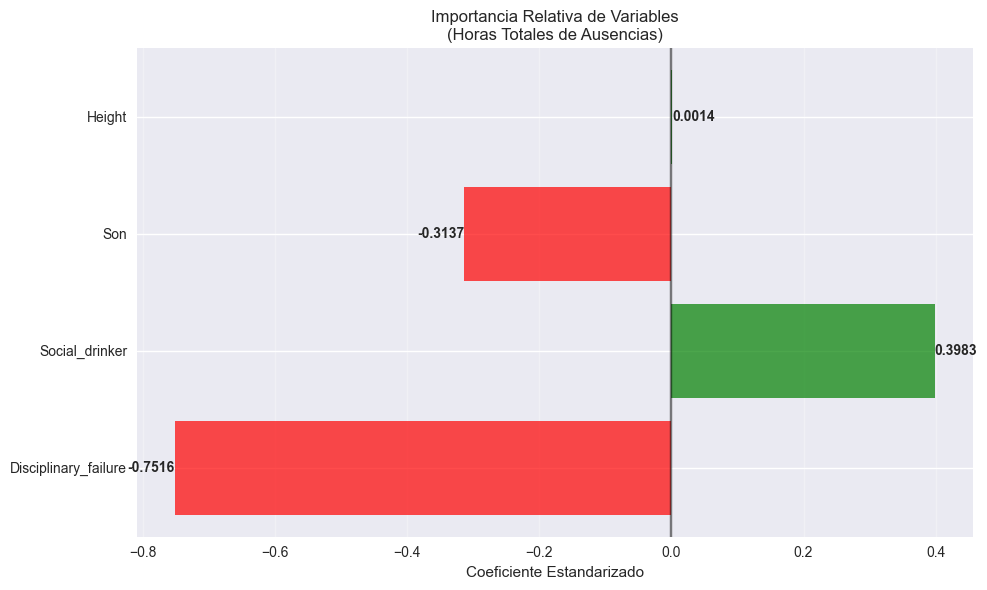

In [152]:
# Importancia relativa de las variables (usando coeficientes estandarizados)
from sklearn.preprocessing import StandardScaler

# Estandarizar variables para comparar coeficientes
scaler_horas = StandardScaler()
X_scaled_horas = scaler_horas.fit_transform(X)
X_scaled_horas = pd.DataFrame(X_scaled_horas, columns=variables_modelo)

# Modelo con variables estandarizadas
modelo_estandarizado_horas = LinearRegression()
modelo_estandarizado_horas.fit(X_scaled_horas, y)

print("\n🎯 IMPORTANCIA RELATIVA DE VARIABLES - HORAS TOTALES")
print("="*65)

coeficientes_estandarizados_horas = pd.DataFrame({
    'Variable': variables_modelo,
    'Coeficiente': modelo_estandarizado_horas.coef_,
    'Absoluto': np.abs(modelo_estandarizado_horas.coef_)
}).sort_values('Absoluto', ascending=False)

for idx, row in coeficientes_estandarizados_horas.iterrows():
    direccion = "positiva" if row['Coeficiente'] > 0 else "negativa"
    print(f"  • {row['Variable']}: {row['Coeficiente']:.4f} ({direccion})")

# Gráfico de importancia
plt.figure(figsize=(10, 6))
colors = ['green' if coef > 0 else 'red' for coef in coeficientes_estandarizados_horas['Coeficiente']]
bars = plt.barh(coeficientes_estandarizados_horas['Variable'], 
                coeficientes_estandarizados_horas['Coeficiente'], 
                color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.xlabel('Coeficiente Estandarizado')
plt.title('Importancia Relativa de Variables\n(Horas Totales de Ausencias)')
plt.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left' if width >= 0 else 'right', 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [156]:
print("🔍 ANÁLISIS DETALLADO DE LOS RESULTADOS")
print("="*50)

print("🎯 ORDEN DE IMPORTANCIA (de mayor a menor):")
print("1. Disciplinary_failure: -0.7516 (MÁS IMPORTANTE)")
print("2. Social_drinker: 0.3983")
print("3. Son: -0.3137") 
print("4. Height: 0.0014 (MENOS IMPORTANTE)")

print(f"\n📊 INTERPRETACIÓN DE COEFICIENTES ESTANDARIZADOS:")
print("(Por cada desviación estándar de cambio en la variable predictora)")

🔍 ANÁLISIS DETALLADO DE LOS RESULTADOS
🎯 ORDEN DE IMPORTANCIA (de mayor a menor):
1. Disciplinary_failure: -0.7516 (MÁS IMPORTANTE)
2. Social_drinker: 0.3983
3. Son: -0.3137
4. Height: 0.0014 (MENOS IMPORTANTE)

📊 INTERPRETACIÓN DE COEFICIENTES ESTANDARIZADOS:
(Por cada desviación estándar de cambio en la variable predictora)


In [157]:
# Calcular desviaciones estándar para interpretación
std_horas = y.std()
print(f"\n💡 INTERPRETACIÓN PRÁCTICA:")
print(f"Desviación estándar de horas totales: {std_horas:.1f} horas")
print()

# Disciplinary_failure
efecto_failure = -0.7516 * std_horas
print(f"1. FALLO DISCIPLINARIO (Coef: -0.7516):")
print(f"   • Los empleados CON fallo disciplinario tienen")
print(f"     {abs(efecto_failure):.1f} horas MENOS de absentismo")
print(f"   • Esto es CONTRARIO a lo esperado normalmente")
print(f"   • Posibles explicaciones:")
print(f"     - Empleados problemáticos evitan ausentarse para no llamar más la atención")
print(f"     - Sesgo en los datos o variable proxy de otra característica")

# Social_drinker
efecto_drinker = 0.3983 * std_horas
print(f"\n2. CONSUMO DE ALCOHOL (Coef: 0.3983):")
print(f"   • Los bebedores sociales tienen")
print(f"     {efecto_drinker:.1f} horas MÁS de absentismo")
print(f"   • Coherente con expectativas: consumo de alcohol → más ausencias")

# Son
efecto_hijos = -0.3137 * std_horas
print(f"\n3. NÚMERO DE HIJOS (Coef: -0.3137):")
print(f"   • Por cada hijo adicional, hay")
print(f"     {abs(efecto_hijos):.1f} horas MENOS de absentismo")
print(f"   • Contraintuitivo: normalmente más hijos → más ausencias")
print(f"   • Posibles explicaciones:")
print(f"     - Empleados con hijos necesitan más el empleo → menos ausencias")
print(f"     - Mejor organización familiar")

# Height
efecto_altura = 0.0014 * std_horas
print(f"\n4. ALTURA (Coef: 0.0014):")
print(f"   • Efecto prácticamente CERO")
print(f"   • {efecto_altura:.2f} horas por cm de altura")
print(f"   • La altura NO es un predictor relevante del absentismo")


💡 INTERPRETACIÓN PRÁCTICA:
Desviación estándar de horas totales: 13.9 horas

1. FALLO DISCIPLINARIO (Coef: -0.7516):
   • Los empleados CON fallo disciplinario tienen
     10.4 horas MENOS de absentismo
   • Esto es CONTRARIO a lo esperado normalmente
   • Posibles explicaciones:
     - Empleados problemáticos evitan ausentarse para no llamar más la atención
     - Sesgo en los datos o variable proxy de otra característica

2. CONSUMO DE ALCOHOL (Coef: 0.3983):
   • Los bebedores sociales tienen
     5.5 horas MÁS de absentismo
   • Coherente con expectativas: consumo de alcohol → más ausencias

3. NÚMERO DE HIJOS (Coef: -0.3137):
   • Por cada hijo adicional, hay
     4.3 horas MENOS de absentismo
   • Contraintuitivo: normalmente más hijos → más ausencias
   • Posibles explicaciones:
     - Empleados con hijos necesitan más el empleo → menos ausencias
     - Mejor organización familiar

4. ALTURA (Coef: 0.0014):
   • Efecto prácticamente CERO
   • 0.02 horas por cm de altura
   • La

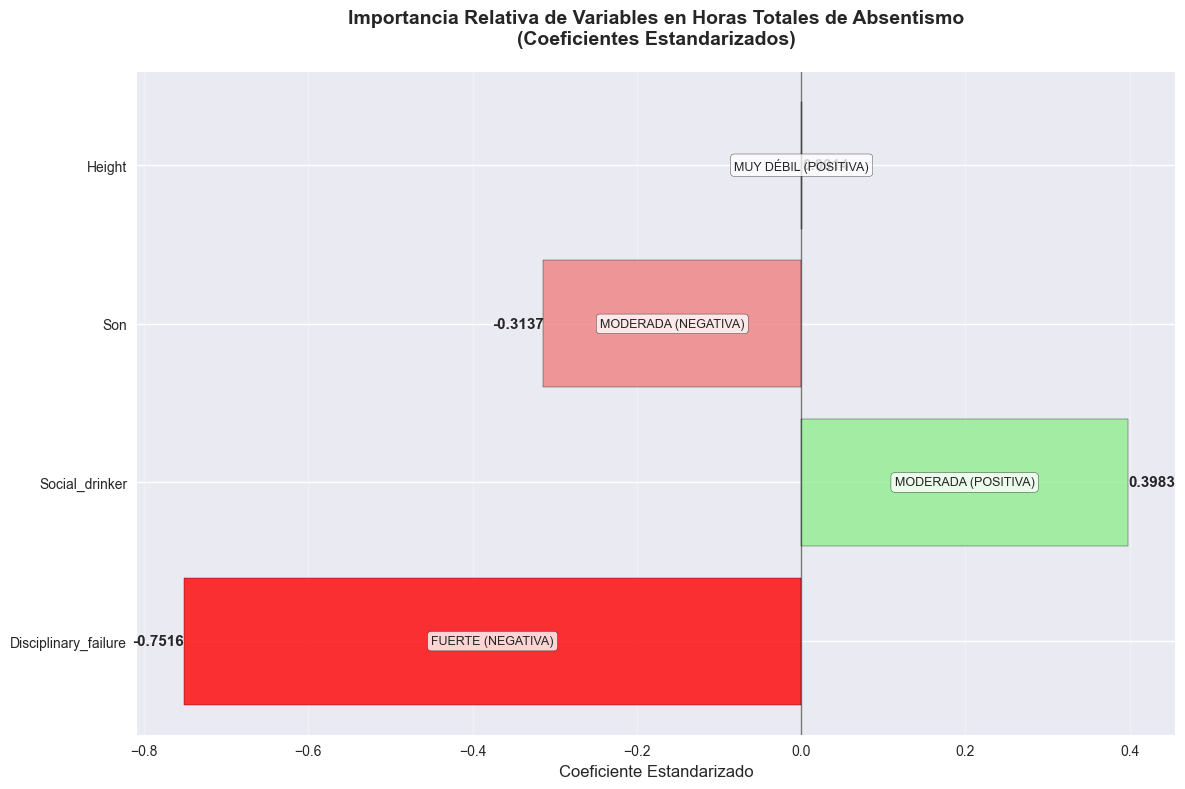

In [158]:
# Gráfico mejorado de importancia
plt.figure(figsize=(12, 8))

# Preparar datos
variables = coeficientes_estandarizados_horas['Variable']
coeficientes = coeficientes_estandarizados_horas['Coeficiente']
abs_coef = coeficientes_estandarizados_horas['Absoluto']

# Crear colores según dirección e importancia
colors = []
for coef in coeficientes:
    if abs(coef) > 0.5:
        color = 'red' if coef < 0 else 'darkgreen'
    elif abs(coef) > 0.3:
        color = 'lightcoral' if coef < 0 else 'lightgreen'
    else:
        color = 'lightgray'
    colors.append(color)

# Gráfico principal
bars = plt.barh(range(len(variables)), coeficientes, color=colors, alpha=0.8, edgecolor='black')

plt.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.xlabel('Coeficiente Estandarizado', fontsize=12)
plt.title('Importancia Relativa de Variables en Horas Totales de Absentismo\n(Coeficientes Estandarizados)', 
          fontsize=14, fontweight='bold', pad=20)
plt.yticks(range(len(variables)), variables)

# Añadir valores y etiquetas detalladas
for i, (bar, coef, abs_coef) in enumerate(zip(bars, coeficientes, abs_coef)):
    width = bar.get_width()
    
    # Texto del valor
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'{coef:.4f}', 
             ha='left' if width >= 0 else 'right', 
             va='center', fontweight='bold', fontsize=11)
    
    # Etiqueta de fuerza
    if abs_coef > 0.7:
        fuerza = "FUERTE"
    elif abs_coef > 0.5:
        fuerza = "MODERADA-FUERTE"
    elif abs_coef > 0.3:
        fuerza = "MODERADA"
    elif abs_coef > 0.1:
        fuerza = "DÉBIL"
    else:
        fuerza = "MUY DÉBIL"
    
    direccion = "NEGATIVA" if coef < 0 else "POSITIVA"
    plt.text(width/2, bar.get_y() + bar.get_height()/2, 
             f'{fuerza} ({direccion})', 
             ha='center', va='center', fontsize=9, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [159]:
print("\n🎯 RECOMENDACIONES PARA GESTIÓN DE RECURSOS HUMANOS")
print("="*55)

print("🔴 VARIABLES CRÍTICAS (Enfoque prioritario):")
print("1. FALLO DISCIPLINARIO:")
print("   • Investigar por qué correlaciona con MENOS absentismo")
print("   • Revisar políticas disciplinarias")
print("   • Posible indicador de empleados 'presentistas'")

print("\n🟡 VARIABLES IMPORTANTES (Monitorizar):")
print("2. CONSUMO DE ALCOHOL:")
print("   • Implementar programas de wellness")
print("   • Ofrecer apoyo para problemas de consumo")
print("   • Educación sobre consumo responsable")

print("3. NÚMERO DE HIJOS:")
print("   • Revisar políticas de conciliación familiar")
print("   • Ofrecer flexibilidad horaria")
print("   • Considerar guardería empresarial")

print("\n⚪ VARIABLES NO RELEVANTES (No enfocar recursos):")
print("4. ALTURA:")
print("   • No es predictor útil del absentismo")
print("   • Enfocar recursos en variables más relevantes")


🎯 RECOMENDACIONES PARA GESTIÓN DE RECURSOS HUMANOS
🔴 VARIABLES CRÍTICAS (Enfoque prioritario):
1. FALLO DISCIPLINARIO:
   • Investigar por qué correlaciona con MENOS absentismo
   • Revisar políticas disciplinarias
   • Posible indicador de empleados 'presentistas'

🟡 VARIABLES IMPORTANTES (Monitorizar):
2. CONSUMO DE ALCOHOL:
   • Implementar programas de wellness
   • Ofrecer apoyo para problemas de consumo
   • Educación sobre consumo responsable
3. NÚMERO DE HIJOS:
   • Revisar políticas de conciliación familiar
   • Ofrecer flexibilidad horaria
   • Considerar guardería empresarial

⚪ VARIABLES NO RELEVANTES (No enfocar recursos):
4. ALTURA:
   • No es predictor útil del absentismo
   • Enfocar recursos en variables más relevantes


In [160]:
print("\n💡 POSIBLES EXPLICACIONES PARA RESULTADOS CONTRAINTUITIVOS")
print("="*60)

print("🔍 PARA FALLO DISCIPLINARIO NEGATIVO:")
print("   • 'Presentismo': Empleados problemáticos evitan ausentarse")
print("   • Miedo a perder el empleo después de una sanción")
print("   • Variable proxy: empleados en puestos de mayor supervisión")
print("   • Sesgo de medición: diferentes criterios por departamento")

print("\n🔍 PARA HIJOS NEGATIVO:")
print("   • Mayor responsabilidad financiera → menos ausencias")
print("   • Mejor organización del tiempo familiar")
print("   • Empleados con hijos en puestos más estables")
print("   • Edad como variable confusora (más hijos → más edad)")

print("\n🔍 PARA ALTURA PRÁCTICAMENTE CERO:")
print("   • La altura no tiene relación causal con el absentismo")
print("   • Posible correlación espuria en análisis bivariados")
print("   • Variable irrelevante para políticas de RRHH")


💡 POSIBLES EXPLICACIONES PARA RESULTADOS CONTRAINTUITIVOS
🔍 PARA FALLO DISCIPLINARIO NEGATIVO:
   • 'Presentismo': Empleados problemáticos evitan ausentarse
   • Miedo a perder el empleo después de una sanción
   • Variable proxy: empleados en puestos de mayor supervisión
   • Sesgo de medición: diferentes criterios por departamento

🔍 PARA HIJOS NEGATIVO:
   • Mayor responsabilidad financiera → menos ausencias
   • Mejor organización del tiempo familiar
   • Empleados con hijos en puestos más estables
   • Edad como variable confusora (más hijos → más edad)

🔍 PARA ALTURA PRÁCTICAMENTE CERO:
   • La altura no tiene relación causal con el absentismo
   • Posible correlación espuria en análisis bivariados
   • Variable irrelevante para políticas de RRHH


In [161]:
print("\n" + "="*70)
print("CONCLUSIONES EJECUTIVAS - MODELO DE HORAS TOTALES")
print("="*70)

print(f"\n✅ HALLAZGOS PRINCIPALES:")
print(f"1. El fallo disciplinario es el predictor MÁS FUERTE (coef: -0.7516)")
print(f"2. El consumo de alcohol aumenta el absentismo (coef: 0.3983)")
print(f"3. Más hijos se asocia con MENOS absentismo (coef: -0.3137)")
print(f"4. La altura NO es predictiva (coef: 0.0014)")

print(f"\n⚠️  RESULTADOS SORPRENDENTES:")
print(f"• Relación NEGATIVA fallo disciplinario-absentismo")
print(f"• Relación NEGATIVA hijos-absentismo")

print(f"\n🎯 ACCIONES RECOMENDADAS:")
print(f"1. INVESTIGAR: Por qué empleados disciplinados se ausentan menos")
print(f"2. INTERVENIR: Programas wellness para consumo de alcohol")
print(f"3. APOYAR: Políticas de conciliación (aunque efecto es positivo)")
print(f"4. IGNORAR: La altura como variable predictiva")

print(f"\n📊 EFICACIA DEL MODELO:")
print(f"• Explica el {r2*100:.1f}% de la variabilidad en horas de absentismo")
print(f"• Error promedio: {mae:.1f} horas por empleado")
print("="*70)


CONCLUSIONES EJECUTIVAS - MODELO DE HORAS TOTALES

✅ HALLAZGOS PRINCIPALES:
1. El fallo disciplinario es el predictor MÁS FUERTE (coef: -0.7516)
2. El consumo de alcohol aumenta el absentismo (coef: 0.3983)
3. Más hijos se asocia con MENOS absentismo (coef: -0.3137)
4. La altura NO es predictiva (coef: 0.0014)

⚠️  RESULTADOS SORPRENDENTES:
• Relación NEGATIVA fallo disciplinario-absentismo
• Relación NEGATIVA hijos-absentismo

🎯 ACCIONES RECOMENDADAS:
1. INVESTIGAR: Por qué empleados disciplinados se ausentan menos
2. INTERVENIR: Programas wellness para consumo de alcohol
3. APOYAR: Políticas de conciliación (aunque efecto es positivo)
4. IGNORAR: La altura como variable predictiva

📊 EFICACIA DEL MODELO:
• Explica el -8.5% de la variabilidad en horas de absentismo
• Error promedio: 8.3 horas por empleado
